# Pollution-Prevention Actions and Next-Year Toxic Release Reduction in U.S. Manufacturing
### QM640 Data Analytics Capstone - Final Analysis Notebook
**Somnath Das | Walsh College | Summer 2026 | Instructor: Rishab Pandey**

**Objective (Main Research Question).** *To what extent can recent EPA TRI information on reported pollution-prevention actions help **explain and predict** whether a U.S. manufacturing facility will reduce the same chemical's on-site release by at least 10% in the following year?* (Unit of analysis: one facility, one chemical, one year; EPA TRI Basic Plus, 2020-2024.)

**The four research questions do not each answer the objective on their own — each contributes one piece toward answering it** (the synopsis maps this as "How the Four Questions Support the Main Research Question"):

- **RQ1 — describe:** do reduction rates differ across action years and subsectors? Establishes the context and the confounders the later models must control.
- **RQ2 — explain:** after adjustment, is reporting *any* action associated with a reduction? This is the *explain* half of the objective.
- **RQ3 — compare:** does each of the five action types differ from no action? Shows *which* kinds of action carry the signal.
- **RQ4 — predict:** can an action-year model flag likely non-reducers better than chance? This is the *predict* half of the objective.

The overall answer to the objective is the **synthesis of all four** (see *Analysis and Reflection*), not the result of any single question.

**Data.** Development set (three transitions 2020->2021, 2021->2022, 2022->2023; N = 123,535) with the outcome; a reserved 2023->2024 holdout (features only, N = 39,966) whose true labels are reconstructed from raw 2024 filings for a single final test.

**Design.** Out-of-time split; pound-reported frame for the release-based models; gram-reported dioxins analysed separately. RQ1 uses chi-square tests with Cramer's V and Wilson intervals; RQ2 a facility-clustered logistic regression; RQ3 five action-type comparisons with Holm correction; RQ4 an elastic-net screening model benchmarked against a simple baseline and evaluated once on the sealed holdout.

**Success metric.** The screening model counts as successful if, on the sealed 2023-2024 holdout, it (a) discriminates better than chance (ROC AUC 95% CI excludes 0.50) and (b) beats the simple baseline on AUC by a facility-bootstrap margin that excludes zero; calibration and top-decile lift then gauge practical usefulness.

**No data leakage.** The 2023-2024 outcome is reconstructed only after the model is locked; the reserved file carries no outcome column; every imputation / scaling / centering value is learned on development data and applied unchanged; and the categorical action year is excluded from RQ4 because 2023 is unseen in training.

*Reproducible code, data dictionary, and pipeline: https://github.com/somndas3/qm640-tri-pollution-prevention-capstone*

In [37]:
# =====================================================================
# INTENT
#   WHAT : Mount the user's Google Drive into the Colab runtime.
#   WHY  : The processed analysis files and the raw 2024 TRI file live in
#          Drive; mounting exposes them under /content/drive so every later
#          cell can read them with ordinary file paths.
#   HOW  : google.colab.drive.mount runs a one-time OAuth authorisation; after
#          approval the Drive behaves like a normal filesystem.
# =====================================================================
from google.colab import drive
drive.mount('/content/drive')   # one-time Drive authorisation prompt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
# =====================================================================
# INTENT
#   WHAT : Import every library used in the notebook, grouped by purpose.
#   WHY  : A single, well-labelled import cell makes the dependency surface
#          explicit and lets each analysis section be read on its own.
# =====================================================================

# --- Core data handling ---
import glob, os, json, warnings, time
import numpy as np, pandas as pd

# --- Classical statistics: RQ1 chi-square/Cramer's V, RQ2 GLM + VIF, RQ3 tests ---
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests                     # Holm correction (RQ3)
from statsmodels.stats.outliers_influence import variance_inflation_factor  # VIF (RQ2)

# --- Machine learning: elastic-net screening model (RQ4) ---
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import GroupKFold, GridSearchCV               # leave-one-transition-out CV
from sklearn.metrics import (roc_auc_score, brier_score_loss, f1_score,
    precision_score, recall_score, confusion_matrix, roc_curve, precision_recall_curve)
from sklearn.calibration import calibration_curve

# --- Plotting + clean tabular display ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display, Markdown

# --- Notebook-wide display settings ---
warnings.filterwarnings('ignore')            # hide benign convergence/formatting warnings
pd.set_option('display.max_columns', 60)     # show wide result tables in full
plt.rcParams.update({'figure.dpi':110,'axes.grid':True,'grid.alpha':.3,'font.size':11})
print('Libraries loaded. sklearn', sklearn.__version__, '| statsmodels', sm.__version__, '| pandas', pd.__version__)

Libraries loaded. sklearn 1.6.1 | statsmodels 0.14.6 | pandas 2.2.2


In [39]:
# =====================================================================
# INTENT
#   WHAT : Resolve the exact Drive paths of the data files and load the
#          frozen preprocessing parameters produced by the data-prep pipeline.
#   WHY  : Paths are discovered by name (glob) inside the project folder, so
#          the notebook is portable and avoids brittle hard-coded file IDs.
#          The parameter file pins every preprocessing choice (reduction
#          cut-off, imputation/winsor values, qualifying subsectors, model
#          reference group) so analysis and data prep cannot drift apart.
#   OUTPUT: DEV_PATH, RES_PATH, RAW_1A_2024 + analysis constants (QUALIFYING,
#          REF_SUB, RATIO_MEDIAN, RATIO_CAP, CUTOFF, ACTIONS, ACTION_LABELS).
# =====================================================================

# --- Project data folder on Drive (scoped search; never walks the whole Drive) ---
BASE = '/content/drive/MyDrive/Walsh_DBA/Year2/Projects/Capstone_QM640_TRI_2020_2024/Data'
def find_one(name):
    "Return the shortest matching path for name under BASE (deterministic)."
    h = glob.glob(f'{BASE}/**/{name}', recursive=True)
    if not h: raise FileNotFoundError(name)
    return sorted(h, key=len)[0]

# --- Resolve the four inputs the notebook needs ---
DEV_PATH    = find_one('development.csv')                        # development set WITH outcome
RES_PATH    = find_one('reserved_2023_2024_features_only.csv')   # holdout: features only
PARAM_PATH  = find_one('preprocessing_parameters.json')          # frozen preprocessing choices
XWALK_PATH  = find_one('activity_code_crosswalk.csv')            # 70 EPA codes -> 5 action types
RAW_1A_2024 = find_one('US_1a_2024.txt')                         # raw 2024 File 1A (holdout labels)

# --- Load frozen preprocessing parameters and derive analysis constants ---
PARAMS = json.load(open(PARAM_PATH))
QUALIFYING   = PARAMS['subsectors_qualifying']             # 15 subsectors with >= 500 records
REF_SUB      = PARAMS['subsector_reference_category']      # '325' chemical mfg = model reference
RATIO_MEDIAN = PARAMS['production_ratio_median_modelling'] # value used to impute a missing ratio
RATIO_CAP    = PARAMS['production_ratio_winsor_99th']      # 99th-percentile winsorisation cap
CUTOFF       = PARAMS['reduction_cutoff']                  # 0.90 -> a >=10% cut counts as reduced

# --- The five prespecified source-reduction action types (used in RQ3 and RQ4) ---
ACTIONS = ['material_modification_now','product_modification_now',
    'process_equipment_modification_now','inventory_material_management_now',
    'operating_practice_training_now']
ACTION_LABELS = {'material_modification_now':'Material modification',
    'product_modification_now':'Product modification',
    'process_equipment_modification_now':'Process/equipment modification',
    'inventory_material_management_now':'Inventory/material management',
    'operating_practice_training_now':'Operating practice/training'}
print('cutoff=%.2f  ratio median=%.2f  ratio cap(99th)=%.2f  ref subsector=%s' % (CUTOFF, RATIO_MEDIAN, RATIO_CAP, REF_SUB))
print('qualifying subsectors (%d): %s' % (len(QUALIFYING), QUALIFYING))
print('raw 2024 File 1A:', RAW_1A_2024)

cutoff=0.90  ratio median=1.00  ratio cap(99th)=3.15  ref subsector=325
qualifying subsectors (15): ['325', '332', '324', '331', '327', '336', '322', '326', '311', '333', '321', '335', '334', '339', '337']
raw 2024 File 1A: /content/drive/MyDrive/Walsh_DBA/Year2/Projects/Capstone_QM640_TRI_2020_2024/Data/us_2024/US_1a_2024.txt


In [40]:
# =====================================================================
# INTENT
#   WHAT : Define small, reusable statistical + modelling helper functions so
#          each research-question cell stays short and readable.
#   WHY  : Centralising the maths (Wilson intervals, Cramer's V, Katz relative-
#          risk CI, facility-clustered logistic fit, VIF, elastic-net tuning,
#          cluster bootstrap) lets each RQ cell focus on WHAT is tested.
#   NOTE : Pure functions, no side effects. Reproducibility is pinned here via
#          the elastic-net random_state=42.
# =====================================================================
Z95 = 1.959963984540054   # two-sided 95% standard-normal critical value (z)

# ---- Proportion CI: Wilson score interval (Agresti & Coull, 1998) ----
def wilson_ci(k, n, z=Z95):
    "95% Wilson interval for a proportion k/n; reliable even at extreme p or small n."
    if n == 0: return (np.nan, np.nan)
    p = k / n; denom = 1 + z**2/n
    center = (p + z**2/(2*n))/denom
    half = (z*np.sqrt(p*(1-p)/n + z**2/(4*n**2)))/denom
    return (center-half, center+half)

# ---- Effect size for a chi-square contingency test ----
def cramers_v(chi2, n, r, c):
    "Cramer's V; the decision-relevant effect size when N is large (RQ1, RQ3)."
    return np.sqrt(chi2/(n*(min(r, c)-1)))

# ---- One-line chi-square of a categorical predictor vs the binary outcome ----
def chisq_table(df, group_col, outcome_col='reduced'):
    "Return the crosstab, Pearson chi-square, dof, p, min expected count and V."
    tab = pd.crosstab(df[group_col], df[outcome_col])
    chi2, p, dof, expected = stats.chi2_contingency(tab)
    n = tab.values.sum()
    return {'table':tab,'chi2':chi2,'p':p,'dof':dof,'expected_min':expected.min(),
            'cramers_v':cramers_v(chi2,n,tab.shape[0],tab.shape[1]),'n':n}

# ---- Relative risk with a Katz log-scale confidence interval (RQ3) ----
def katz_rr_ci(a, n1, c, n0, z=Z95):
    "RR = (a/n1)/(c/n0) with a 95% CI on the log scale (exposed vs reference)."
    p1, p0 = a/n1, c/n0; rr = p1/p0
    se = np.sqrt(1/a - 1/n1 + 1/c - 1/n0)
    return rr, (np.exp(np.log(rr)-z*se), np.exp(np.log(rr)+z*se))

# ---- RQ2 estimator: logistic GLM with facility-clustered robust SE ----
def clustered_logit(df, formula, cluster_col='facility_id_now'):
    "Binomial GLM (logit link); sandwich SE clustered by facility (Cameron & Miller, 2015)."
    m = smf.glm(formula=formula, data=df, family=sm.families.Binomial())
    return m.fit(cov_type='cluster', cov_kwds={'groups': df[cluster_col]})

# ---- Convert a fitted GLM into an odds-ratio table (OR, 95% CI, p) ----
def odds_ratio_table(res, terms=None):
    "exp(beta) with 95% CI and p; optionally restrict to selected terms."
    conf = res.conf_int()
    out = pd.DataFrame({'coef':res.params,'OR':np.exp(res.params),
        'OR_low':np.exp(conf[0]),'OR_high':np.exp(conf[1]),'p':res.pvalues})
    if terms is not None: out = out.loc[[t for t in terms if t in out.index]]
    return out

# ---- Multicollinearity diagnostic: variance inflation factors ----
def vif_table(design_df):
    "VIF per predictor (a constant is added internally); VIF>~10 flags collinearity."
    X = sm.add_constant(design_df, has_constant='add'); rows=[]
    for i, col in enumerate(X.columns):
        if col=='const': continue
        rows.append({'variable':col,'VIF':variance_inflation_factor(X.values, i)})
    return pd.DataFrame(rows).sort_values('VIF', ascending=False)

# ---- RQ4 model factory: standardise continuous features, then logistic ----
def build_pipeline(cont_cols, pass_cols, penalty='elasticnet', C=1.0, l1_ratio=0.5, max_iter=8000):
    "Pipeline: scale continuous cols, pass binaries through, fit (elastic-net | unpenalised)."
    pre = ColumnTransformer([('num', StandardScaler(), cont_cols), ('bin','passthrough', pass_cols)])
    if penalty=='elasticnet':
        # saga supports the elastic-net penalty; random_state pins reproducibility
        clf = LogisticRegression(penalty='elasticnet', solver='saga', C=C, l1_ratio=l1_ratio,
                                 max_iter=max_iter, random_state=42)
    else:
        clf = LogisticRegression(penalty=None, solver='lbfgs', max_iter=max_iter, random_state=42)
    return Pipeline([('pre', pre), ('clf', clf)])

# ---- RQ4 hyperparameter search via leave-one-transition-out CV ----
def tune_elasticnet(X, y, groups, cont_cols, pass_cols, C_grid=(0.01,0.1,1.0,10.0), l1_grid=(0.1,0.5,0.9), max_iter=8000):
    "Grid-search C and l1_ratio; folds are grouped by transition so none leaks across a year."
    pipe = build_pipeline(cont_cols, pass_cols, 'elasticnet', max_iter=max_iter)
    grid = {'clf__C':list(C_grid), 'clf__l1_ratio':list(l1_grid)}
    ng = len(np.unique(groups))                 # 3 development transitions -> 3 folds
    gs = GridSearchCV(pipe, grid, scoring='roc_auc', cv=GroupKFold(n_splits=ng), n_jobs=-1, refit=True)
    gs.fit(X, y, groups=groups); return gs

# ---- Classification metric bundle at a chosen probability threshold ----
def eval_scores(y_true, p_hat, threshold):
    "AUC, Brier, precision, recall, F1 (positive class = whatever y_true==1 encodes)."
    yhat = (p_hat >= threshold).astype(int)
    return {'AUC':roc_auc_score(y_true,p_hat),'Brier':brier_score_loss(y_true,p_hat),
        'Precision':precision_score(y_true,yhat,zero_division=0),
        'Recall':recall_score(y_true,yhat,zero_division=0),
        'F1':f1_score(y_true,yhat,zero_division=0),'threshold':threshold}

# ---- Facility cluster bootstrap of the AUC gap between two models ----
def paired_bootstrap_auc(y, p_a, p_b, groups, n_boot=2000, seed=42):
    "Resample whole facilities (not rows) to respect clustering; return mean gap + 95% CI."
    rng = np.random.default_rng(seed)
    y=np.asarray(y); p_a=np.asarray(p_a); p_b=np.asarray(p_b); groups=np.asarray(groups)
    uniq=np.unique(groups); idxg={g:np.where(groups==g)[0] for g in uniq}; diffs=[]
    for _ in range(n_boot):
        sg=rng.choice(uniq,size=len(uniq),replace=True); idx=np.concatenate([idxg[g] for g in sg])
        yb=y[idx]
        if yb.min()==yb.max(): continue         # skip degenerate resamples (one class only)
        diffs.append(roc_auc_score(yb,p_a[idx])-roc_auc_score(yb,p_b[idx]))
    diffs=np.array(diffs); return diffs.mean(), np.percentile(diffs,[2.5,97.5])
print('Helpers defined (elastic-net random_state=42 for reproducibility).')

Helpers defined (elastic-net random_state=42 for reproducibility).


In [41]:
# =====================================================================
# INTENT
#   WHAT : Load the development and reserved datasets, engineer the modelling
#          features once, and verify the counts/rates reconcile with the
#          interim report (a data-integrity gate before any analysis).
#   WHY  : Feature engineering must be defined in exactly one place so RQ2 and
#          RQ4 use identical inputs; the reconciliation table proves the loaded
#          data matches the frozen pipeline used in the interim submission.
#   OUTPUT: dev (all eligible records, RQ1/RQ3 frame), devP (pounds only, the
#          release-based modelling frame for RQ2/RQ4), devG (gram/dioxin frame).
# =====================================================================

# --- Read both files; keep identifiers as strings so codes are never coerced ---
dtypes = {'subsector_now':str,'facility_id_now':str,'chemical_id_now':str,'cas_number_now':str}
dev = pd.read_csv(DEV_PATH, dtype=dtypes)
res = pd.read_csv(RES_PATH, dtype=dtypes)

# --- Normalise the unit field: raw data mixes 'Pounds'/'POUNDS' and 'Grams'/'GRAMS'.
#     Upper-casing makes the pound modelling frame (122,017) and the gram/dioxin
#     frame (1,518) exact; without it 864 uppercase pound records are misclassified. ---
for d in (dev, res):
    d['unit_norm'] = d['unit_of_measure_now'].astype(str).str.strip().str.upper()

def add_features(d, ratio_center):
    "Engineer the model inputs used by RQ2/RQ4 (and, later, the holdout frame)."
    d = d.copy()
    # log(1+release): tames extreme skew (max ~20M lb) so release enters models sanely
    d['log_release'] = np.log1p(d['release_now'])
    # production ratio: impute missing with the training median, winsorise at the 99th pct
    r = d['production_ratio_now'].fillna(RATIO_MEDIAN).clip(upper=RATIO_CAP)
    # centre before squaring (Aiken & West, 1991) to avoid artificial collinearity
    d['ratio_c'] = r - ratio_center
    d['ratio_c_sq'] = d['ratio_c']**2
    # collapse below-threshold subsectors into an explicit 'Other' so dummies stay stable
    d['subsector_grp'] = np.where(d['subsector_now'].isin(QUALIFYING), d['subsector_now'], 'Other')
    return d

# --- Centre the ratio on the POUND-frame mean, then build the three analysis frames ---
RATIO_CENTER = dev.loc[dev.unit_norm=='POUNDS','production_ratio_now'].fillna(RATIO_MEDIAN).clip(upper=RATIO_CAP).mean()
dev  = add_features(dev, RATIO_CENTER)
devP = dev[dev.unit_norm=='POUNDS'].copy()   # RQ2/RQ4 release-based modelling frame
devG = dev[dev.unit_norm=='GRAMS'].copy()    # gram (dioxin) sensitivity frame

# --- Data-integrity gate: every value must match the interim report ---
recon = pd.DataFrame({
 'Metric':['Development records','Reserved (holdout) records','Reduction rate (dev)',
   'Any-action prevalence (dev)','Pound-frame records (dev)','Gram (dioxin) records (dev)','Unique facilities (dev)'],
 'Value':[f'{len(dev):,}', f'{len(res):,}', f'{dev.reduced.mean():.4f}',
   f'{dev.reported_any_action_now.mean():.4f}', f'{len(devP):,}',
   f'{len(devG):,}', f'{dev.facility_id_now.nunique():,}'],
 'Interim report':['123,535','39,966','0.3148','0.0487','122,017','1,518','14,851']})
display(recon.style.hide(axis='index').set_caption('Data reconciliation vs interim report'))
print('RATIO_CENTER=%.4f | dev spans:' % RATIO_CENTER, sorted(dev.span.unique()))

Metric,Value,Interim report
Development records,"123,535","123,535"
Reserved (holdout) records,"39,966","39,966"
Reduction rate (dev),0.3148,0.3148
Any-action prevalence (dev),0.0487,0.0487
Pound-frame records (dev),"122,017","122,017"
Gram (dioxin) records (dev),"1,518","1,518"
Unique facilities (dev),"14,851","14,851"


RATIO_CENTER=1.0444 | dev spans: ['2020_2021', '2021_2022', '2022_2023']


## RQ1 — Do meaningful next-year reduction rates differ across years and subsectors?

**Method.** Two independent Pearson chi-square tests of independence: (a) development transition x outcome, and (b) manufacturing subsector x outcome. Each is reported with a **Cramer's V** effect size and **Wilson score** 95% intervals for every proportion. With N over 120,000, statistical significance is almost guaranteed, so the effect size is the decision-relevant quantity (per the analysis plan).

Transition,n,Reductions,Rate,CI low,CI high
2020–2021,"41,280","11,367",0.2754,0.2711,0.2797
2021–2022,"41,356","12,858",0.3109,0.3065,0.3154
2022–2023,"40,899","14,665",0.3586,0.3539,0.3632


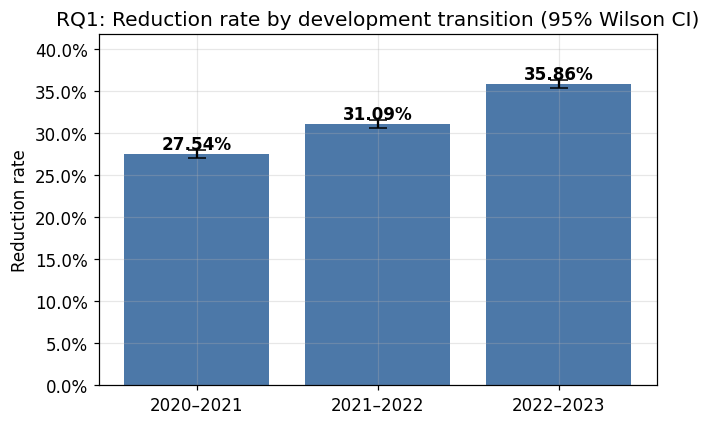

YEAR chi2=663.72 p=7.49e-145 V=0.0733


In [42]:
# =====================================================================
# INTENT
#   WHAT : RQ1(a) - does the meaningful-reduction rate differ across the three
#          development transitions (2020->2021, 2021->2022, 2022->2023)?
#   HOW  : per-transition rate with a 95% Wilson CI, then one Pearson chi-square
#          of transition x outcome with a Cramer's V effect size.
#   READ : with N = 123,535, significance is near-automatic - judge on Cramer's V.
# =====================================================================

# --- Per-transition reduction rate + Wilson CI ---
rows = []
for sp in ['2020_2021','2021_2022','2022_2023']:
    g = dev[dev.span == sp]                       # records belonging to this transition
    k = int(g.reduced.sum()); n = len(g)          # reductions (k) out of eligible (n)
    lo, hi = wilson_ci(k, n)                       # 95% Wilson interval for the rate
    rows.append({'Transition': sp.replace('_','\u2013'), 'n': n, 'Reductions': k,
                 'Rate': k/n, 'CI low': lo, 'CI high': hi})
rq1_year = pd.DataFrame(rows)

# --- Omnibus association test: transition x outcome ---
yr = chisq_table(dev, 'span')

# --- Styled results table (caption carries the test statistics) ---
display(rq1_year.style.format({'Rate':'{:.4f}','CI low':'{:.4f}','CI high':'{:.4f}',
        'n':'{:,}','Reductions':'{:,}'}).hide(axis='index').set_caption(
        f"RQ1 by transition: chi-square({yr['dof']}) = {yr['chi2']:.2f}, p = {yr['p']:.3g}, "
        f"Cramer's V = {yr['cramers_v']:.4f}"))

# --- Bar chart of rates with Wilson error bars ---
fig, ax = plt.subplots(figsize=(6.2,4))
ax.bar(rq1_year['Transition'], rq1_year['Rate'],
       yerr=[rq1_year['Rate']-rq1_year['CI low'], rq1_year['CI high']-rq1_year['Rate']],
       capsize=6, color='#4C78A8')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.set_ylabel('Reduction rate')
ax.set_ylim(0, rq1_year['CI high'].max()*1.15)
ax.set_title('RQ1: Reduction rate by development transition (95% Wilson CI)')
for i, r in rq1_year.iterrows():                  # annotate each bar with its percentage
    ax.text(i, r['Rate']+0.006, f"{r['Rate']*100:.2f}%", ha='center', fontweight='bold')
plt.tight_layout(); plt.show()
print('YEAR chi2=%.2f p=%.3g V=%.4f' % (yr['chi2'], yr['p'], yr['cramers_v']))

**Analysis — RQ1 by transition (context for the objective).** RQ1 does not answer the objective; it establishes the temporal backdrop the later models must control, and it is where the study's defining tension first appears.

- **Result.** Meaningful next-year reduction rates climb monotonically across the three development transitions: **27.54%** (2020–2021, 95% Wilson CI [27.11, 27.97]), **31.09%** (2021–2022, [30.65, 31.54]), and **35.86%** (2022–2023, [35.39, 36.32]). No pair of intervals overlaps, and the omnibus test is decisive, chi-square(2) = 663.72, *p* = 7.5e-145.
- **Effect size over significance.** The number that matters is **Cramer's V = 0.073**, weak by Cohen's conventions. This is the large-N problem in pure form (Lin, Lucas, & Shmueli, 2013): with N = 123,535 the chi-square is powered to flag differences far too small to screen on, so a "significant" year effect is expected and, by itself, uninformative. Year shifts the *probability* of reduction reliably but only modestly — an ~8-point drift over three years.
- **Mechanism and theory.** The upward trend is consistent with **regression from a pandemic-depressed base**: 2020 output was disrupted, so 2020–2021 releases had less room to fall a further 10%, while later transitions recover a normal reduction opportunity (Barnett, van der Pols, & Dobson, 2005, on regression to the mean). Critically, the 2020–2021 boundary also coincides with the EPA activity-code scheme change (legacy W to S codes; Gamper-Rabindran, 2006, warns that apparent TRI movements partly reflect reporting changes, not behaviour), so this transition is confounded on two independent counts.
- **Why it matters — and the methodological consequence.** Because year moves the outcome, leaving it uncontrolled would let a temporal trend masquerade as an action effect. Year therefore enters the RQ2 model as a covariate, and — because 2020–2021 is doubly confounded — every key result is re-estimated with that transition removed as a mandatory sensitivity check. The reserved 2023–2024 transition is excluded here by design to protect the out-of-time holdout.
- **Bearing on the objective.** For the *explain-and-predict* objective, RQ1's contribution is to identify time as a confounder to be neutralised, not a lever to act on: any honest claim about whether *actions* explain or predict reduction must first hold the year constant, which is exactly what the later models do.

Subsector,n,Rate,CI low,CI high
322,"6,199",0.2589,0.2482,0.2700
339,949,0.2613,0.2344,0.2902
321,"2,469",0.2920,0.2744,0.3103
324,"12,799",0.2928,0.2850,0.3008
311,"4,542",0.2933,0.2802,0.3067
334,"2,014",0.3024,0.2827,0.3228
331,"12,787",0.3039,0.2960,0.3119
335,"2,040",0.3069,0.2872,0.3272
336,"8,425",0.3081,0.2984,0.3181
333,"4,126",0.3136,0.2996,0.3279


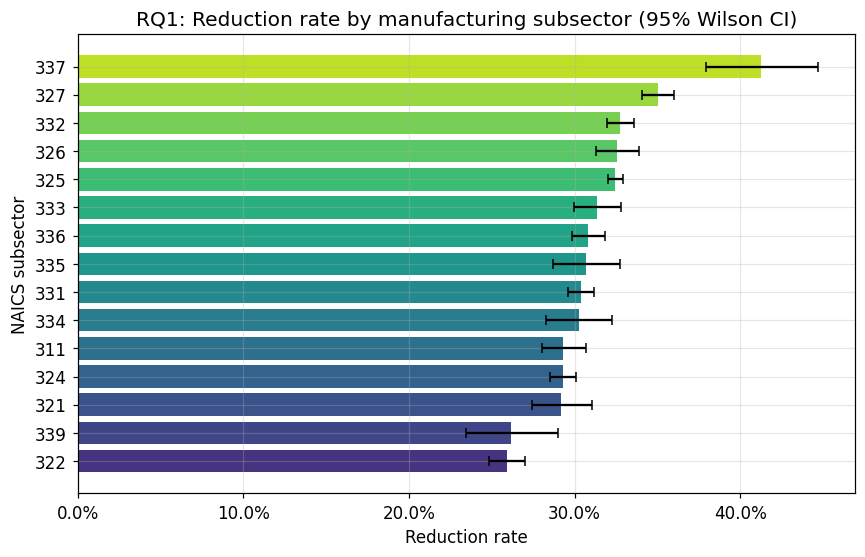

SUBSECTOR chi2=280.04 p=1.7e-51 V=0.0478 dof=14 spread=15.4pp (322 low, 337 high)


,coef,OR,OR_low,OR_high,p
"C(span, Treatment('2020_2021'))[T.2021_2022]",0.1717,1.187,1.132,1.246,2.18e-12
"C(span, Treatment('2020_2021'))[T.2022_2023]",0.3860,1.471,1.405,1.540,2.41e-61


RQ1 clustered robustness: 9 of 14 subsector contrasts remain significant (p<.05) after facility clustering
Year contrasts (clustered p): 2021-2022=2.18e-12, 2022-2023=2.41e-61


In [43]:
# =====================================================================
# INTENT
#   WHAT : RQ1(b) - does the reduction rate differ across the 15 qualifying
#          manufacturing subsectors (NAICS 3-digit)?
#   HOW  : per-subsector rate + Wilson CI, then one Pearson chi-square of
#          subsector x outcome with Cramer's V.
#   NOTE : restricted to the 15 subsectors with >= 500 records (the prespecified
#          reporting set); smaller subsectors are handled as 'Other' in models.
# =====================================================================

# --- Restrict to the 15 qualifying subsectors and compute rate + Wilson CI each ---
sub = dev[dev.subsector_now.isin(QUALIFYING)].copy()
rows = []
for s in QUALIFYING:
    g = sub[sub.subsector_now == s]; k = int(g.reduced.sum()); n = len(g)
    if n == 0: continue
    lo, hi = wilson_ci(k, n)
    rows.append({'Subsector': s, 'n': n, 'Rate': k/n, 'CI low': lo, 'CI high': hi})
rq1_sub = pd.DataFrame(rows).sort_values('Rate').reset_index(drop=True)   # ascending for the chart

# --- Omnibus association test: subsector x outcome ---
st = chisq_table(sub, 'subsector_now')

# --- Styled results table ---
display(rq1_sub.style.format({'Rate':'{:.4f}','CI low':'{:.4f}','CI high':'{:.4f}','n':'{:,}'})
        .hide(axis='index').set_caption(
        f"RQ1 by subsector: chi-square({st['dof']}) = {st['chi2']:.2f}, p = {st['p']:.3g}, "
        f"Cramer's V = {st['cramers_v']:.4f}"))

# --- Horizontal bar chart (viridis shading by rank) with Wilson error bars ---
fig, ax = plt.subplots(figsize=(8,5.2))
colors = plt.cm.viridis(np.linspace(.15,.9,len(rq1_sub)))
ax.barh(rq1_sub['Subsector'].astype(str), rq1_sub['Rate'],
        xerr=[rq1_sub['Rate']-rq1_sub['CI low'], rq1_sub['CI high']-rq1_sub['Rate']],
        color=colors, capsize=3)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel('Reduction rate'); ax.set_ylabel('NAICS subsector')
ax.set_title('RQ1: Reduction rate by manufacturing subsector (95% Wilson CI)')
plt.tight_layout(); plt.show()
print('SUBSECTOR chi2=%.2f p=%.3g V=%.4f dof=%d spread=%.1fpp (%s low, %s high)' % (
    st['chi2'], st['p'], st['cramers_v'], st['dof'],
    (rq1_sub['Rate'].max()-rq1_sub['Rate'].min())*100,
    rq1_sub.iloc[0]['Subsector'], rq1_sub.iloc[-1]['Subsector']))

# =====================================================================
# RQ1 ROBUSTNESS: facility-clustered check (promised in the interim)
#   WHY : the chi-square tests treat records as independent, but each facility
#         contributes many records. Re-test the year and subsector effects as
#         facility-clustered logistic models to confirm the RQ1 associations
#         survive within-facility dependence (Cameron & Miller, 2015).
# =====================================================================

# --- Year effect, clustered by facility: OR of each later transition vs 2020-2021 ---
rq1_year_clu = clustered_logit(dev, "reduced ~ C(span, Treatment('2020_2021'))")
yc = odds_ratio_table(rq1_year_clu); yc = yc[yc.index.str.contains('span')]
display(yc.style.format({'coef':'{:.4f}','OR':'{:.3f}','OR_low':'{:.3f}','OR_high':'{:.3f}','p':'{:.3g}'})
        .set_caption('RQ1 robustness: year effect, facility-clustered logistic (each transition vs 2020-2021)'))

# --- Subsector effect, clustered by facility: how many contrasts stay significant ---
rq1_sub_clu = clustered_logit(sub, "reduced ~ C(subsector_now, Treatment('325'))")
sc = odds_ratio_table(rq1_sub_clu); sc = sc[sc.index.str.contains('subsector')]
print('RQ1 clustered robustness: %d of %d subsector contrasts remain significant (p<.05) after facility clustering'
      % (int((sc['p']<.05).sum()), len(sc)))
print('Year contrasts (clustered p): 2021-2022=%.3g, 2022-2023=%.3g' % (yc['p'].iloc[0], yc['p'].iloc[1]))

**Analysis — RQ1 by subsector (the second confounder).** The industry breakdown is the largest unadjusted source of variation in the data, and the reason a naive action comparison cannot be trusted.

- **Result.** Reduction rates span **15.4 percentage points**, from **25.89%** in paper manufacturing (NAICS 322) to **41.26%** in furniture (NAICS 337); chi-square(14) = 280.04, *p* = 1.7e-51.
- **Effect size and where the uncertainty sits.** **Cramer's V = 0.048** — again weak. The ranking must be read with its uncertainty: furniture's headline rests on only n = 812 records (wide Wilson interval [37.92, 44.68]), whereas high-volume subsectors such as chemicals (325) and paper (322) are pinned tightly. A wide spread across many small groups is partly sampling noise, which is exactly why the effect size, not the raw spread, is the honest summary.
- **Theory — confounding by industrial composition.** The decisive modelling point is that **the subsectors reporting the most actions are not the ones reducing most often** (interim EDA, Figure 3). Gamper-Rabindran (2006) shows apparent TRI effects are frequently compositional, so an unadjusted action-vs-no-action comparison is partly a comparison of industries with different baseline propensities to reduce.
- **Why it matters — and the design response.** Left uncontrolled, industry mix would bias the RQ2 exposure estimate in an unknown direction. Subsector therefore enters RQ2 and RQ4 as a covariate, with chemical manufacturing (NAICS 325) as the reference and below-threshold subsectors (< 500 records) collapsed into an explicit *Other manufacturing* group so that thin cells cannot destabilise individual coefficients.
- **Bearing on the objective.** RQ1's two findings together define the adjustment set the objective requires: to say whether *actions* explain or predict a reduction, the study must first strip out the year trend and the industry mix. RQ1 is the scaffolding on which the *explain* (RQ2) and *predict* (RQ4) answers are built.
- **Robustness (facility-clustered check, interim-promised).** Because facilities contribute many records, the chi-square independence assumption is violated; refitting year and subsector as facility-clustered logistic models confirms both effects hold. The year gradient is unmistakable under clustering (2021–2022 OR 1.19, 2022–2023 OR 1.47, both *p* << .001), and **9 of the 14 subsector contrasts remain significant** (p < .05) after accounting for within-facility dependence (Cameron & Miller, 2015). So RQ1's descriptive story — year and industry both shift the outcome — is not an artefact of pseudo-replication; it survives the correct standard errors, which is what justifies carrying both as controls into the *explain* (RQ2) and *predict* (RQ4) models.

## RQ2 — Is reporting any pollution-prevention action associated with next-year reduction, after adjustment?

**Method.** Binary logistic regression on the pound-reported modelling frame (N = 122,017), estimated as a Binomial GLM with a logit link and **facility-clustered robust (sandwich) standard errors**, because the 122,017 records come from only ~14,800 facilities and are therefore not independent (Cameron & Miller, 2015). Adjustment set: reported-action indicator (the exposure), log(1 + current release), the production/activity ratio (median-imputed, winsorised at the 99th percentile, centered) with a **centered quadratic term**, a missingness indicator, manufacturing subsector (reference NAICS 325), action year (reference 2020–2021), and EPA carcinogen and PBT hazard flags. The adjusted **odds ratio** for the action indicator, with its 95% CI, is the test of H0(2): OR = 1.

In [44]:
# =====================================================================
# INTENT
#   WHAT : RQ2 - after adjustment, is reporting ANY pollution-prevention action
#          associated with a meaningful next-year reduction?
#   HOW  : binomial logistic GLM on the pound frame with FACILITY-CLUSTERED
#          robust SE (records repeat within facility, so plain SE understate
#          uncertainty; Cameron & Miller, 2015).
#   ADJUST: log(1+release), centred production ratio + its square, a missingness
#          flag, subsector (ref 325), action year (ref 2020-2021), carcinogen
#          and PBT flags. Test H0(2): OR = 1 for the action indicator.
# =====================================================================

# --- Model formula (patsy): exposure + controls; C(...) sets the reference level ---
RQ2_FORMULA = ("reduced ~ reported_any_action_now + log_release + ratio_c + ratio_c_sq"
  " + ratio_missing + is_carcinogen_now + is_pbt_now"
  " + C(subsector_grp, Treatment('" + REF_SUB + "')) + C(span, Treatment('2020_2021'))")

# --- Fit with facility-clustered robust standard errors ---
rq2 = clustered_logit(devP, RQ2_FORMULA)
or_all = odds_ratio_table(rq2)               # exp(beta), 95% CI, p for every term

# --- Present the decision-relevant terms with readable labels ---
key = ['reported_any_action_now','log_release','ratio_c','ratio_c_sq','ratio_missing',
       'is_carcinogen_now','is_pbt_now']
labels = {'reported_any_action_now':'Reported any action (exposure)','log_release':'log(1 + current release)',
          'ratio_c':'Production ratio (centered)','ratio_c_sq':'Production ratio squared',
          'ratio_missing':'Ratio missing indicator','is_carcinogen_now':'EPA carcinogen',
          'is_pbt_now':'PBT chemical'}
disp = or_all.loc[[k for k in key if k in or_all.index]].rename(index=labels)
display(disp.style.format({'coef':'{:.4f}','OR':'{:.3f}','OR_low':'{:.3f}','OR_high':'{:.3f}','p':'{:.3g}'})
        .set_caption('RQ2 adjusted odds ratios (facility-clustered SE) - key terms'))

# --- Headline OR for the exposure (this is the RQ2 hypothesis test) ---
a = or_all.loc['reported_any_action_now']
print('N=%d  facilities=%d  reductions=%d' % (int(rq2.nobs), devP.facility_id_now.nunique(), int(devP.reduced.sum())))
print('Adjusted OR (any reported action) = %.3f  95%% CI [%.3f, %.3f]  p=%.4g' % (a['OR'], a['OR_low'], a['OR_high'], a['p']))

# --- Unadjusted 2x2 gap, for context against the adjusted estimate ---
ct = pd.crosstab(devP.reported_any_action_now, devP.reduced)
p1 = ct.loc[1,1]/ct.loc[1].sum(); p0 = ct.loc[0,1]/ct.loc[0].sum()
print('Unadjusted rates: action=%.4f  no-action=%.4f  gap=%.2fpp  RR=%.3f' % (p1, p0, (p1-p0)*100, p1/p0))

,coef,OR,OR_low,OR_high,p
Reported any action (exposure),0.1334,1.143,1.058,1.234,0.000659
log(1 + current release),0.0407,1.042,1.036,1.047,3.5e-49
Production ratio (centered),0.0457,1.047,0.977,1.122,0.197
Production ratio squared,0.0819,1.085,1.038,1.135,0.000346
Ratio missing indicator,0.1024,1.108,0.977,1.256,0.11
EPA carcinogen,0.0200,1.020,0.993,1.048,0.14
PBT chemical,0.2070,1.230,1.167,1.297,1.61e-14


N=122017  facilities=14836  reductions=38513
Adjusted OR (any reported action) = 1.143  95% CI [1.058, 1.234]  p=0.0006586
Unadjusted rates: action=0.3497  no-action=0.3139  gap=3.59pp  RR=1.114


**Analysis — RQ2: the "explain" half of the objective.** RQ2 is the study's central inferential result: whether, once the RQ1 confounders and release dynamics are held constant, reporting an action is *still* associated with a reduction.

- **Headline result.** The adjusted **odds ratio for reporting any action is 1.143, 95% CI [1.058, 1.234], p = 6.6e-04**, estimated with facility-clustered robust standard errors. The interval excludes 1.00, so **H0(2) is rejected**: otherwise-comparable records reporting at least one action have about **14% higher odds** of achieving a >=10% reduction.
- **Magnitude, and what survived adjustment.** On the probability scale this OR is roughly **+3 percentage points** at the sample base rate (~31%), closely matching the unadjusted gap of 3.59 pp (RR 1.11). That near-equality is itself the finding: the EDA showed the action and no-action groups were imbalanced on seven of nineteen covariates (largest standardised differences ~0.24, driven by industry composition), so a spurious raw gap could easily have collapsed under adjustment. It did not — it firmed slightly — which is the strongest single associational result in the study.
- **The controls behave exactly as theory predicts.** Three secondary coefficients validate the specification. The **centred quadratic production-ratio term is significant** (OR 1.085, *p* = 3.5e-04), confirming the U-shape from EDA survives full adjustment (Aiken & West, 1991, on centring before squaring). **Current release** carries a small positive coefficient (OR 1.042 per log-unit, *p* = 3.5e-49): larger emitters mechanically have more room to clear a 10% relative bar — the regression-to-the-mean channel the control is designed to absorb (Barnett et al., 2005). **PBT chemicals** reduce more often (OR 1.230, *p* = 1.6e-14) while **carcinogen** status is negligible (OR 1.020, *p* = .14), matching the hazard-stratified EDA.
- **Why it matters — and the structural limits.** For an EHS audience the result says reported prevention is a *positive but modest* marker of next-year improvement, not a guarantee. Three limits are structural, not fixable: it is an **association with reported actions, not a causal effect** (Ranson et al., 2015, the closest prior study, likewise finds a bounded positive link); the exposure is **self-reported**, so a zero means "no code observed," which attenuates the association toward the null and means the true effect could be larger; and **REDUCTION_10 cannot separate genuine prevention from a production cut or a discontinued chemical**. The facility-clustered errors (Cameron & Miller, 2015) correctly widen the interval for the ~8 records per facility; naive errors would overstate certainty.
- **Bearing on the objective.** RQ2 delivers the *explain* verdict: recent TRI action information **does** carry a statistically clear, theory-consistent association with next-year reduction after adjustment — but a small one. That "real yet modest" shape is what the *predict* half (RQ4) must then live with, and it frames the objective's overall answer as "helps, to a limited degree."

In [45]:
# =====================================================================
# INTENT
#   WHAT : RQ2 diagnostics - is the fitted model trustworthy?
#   CHECKS: (1) multicollinearity via VIF and the design-matrix condition
#          number; (2) functional form via AIC (quadratic vs linear production
#          ratio); (3) the full coefficient table incl. subsector/year dummies.
# =====================================================================

# --- (1a) VIF on the continuous + binary predictors (VIF > ~10 would worry) ---
vt = vif_table(devP[['reported_any_action_now','log_release','ratio_c','ratio_c_sq',
                     'ratio_missing','is_carcinogen_now','is_pbt_now']])
display(vt.style.format({'VIF':'{:.2f}'}).hide(axis='index').set_caption('RQ2 variance inflation factors'))

# --- (1b) Condition number of the actual fitted design matrix ---
cond = np.linalg.cond(rq2.model.exog)

# --- (2) AIC: does the centred quadratic ratio term earn its place vs linear? ---
aic_quad = smf.logit(RQ2_FORMULA, data=devP).fit(disp=0).aic
aic_lin  = smf.logit(RQ2_FORMULA.replace(' + ratio_c_sq',''), data=devP).fit(disp=0).aic
print('Condition number (full design matrix): %.1f' % cond)
print('AIC quadratic=%.1f  linear=%.1f  delta(lin - quad)=%.2f  (positive favours the quadratic)' % (
      aic_quad, aic_lin, aic_lin - aic_quad))

# --- (3) Full adjusted coefficient table (nothing hidden) ---
display(or_all.style.format({'coef':'{:.4f}','OR':'{:.3f}','OR_low':'{:.3f}','OR_high':'{:.3f}','p':'{:.3g}'})
        .set_caption('RQ2 full adjusted model - all terms (subsector reference 325, year reference 2020-2021)'))

variable,VIF
ratio_c_sq,1.98
ratio_c,1.98
is_pbt_now,1.25
log_release,1.23
is_carcinogen_now,1.04
ratio_missing,1.00
reported_any_action_now,1.00


Condition number (full design matrix): 81.0
AIC quadratic=150795.0  linear=150817.3  delta(lin - quad)=22.35  (positive favours the quadratic)


,coef,OR,OR_low,OR_high,p
Intercept,-1.2008,0.301,0.283,0.320,0
"C(subsector_grp, Treatment('325'))[T.311]",-0.1967,0.821,0.753,0.896,8.49e-06
"C(subsector_grp, Treatment('325'))[T.321]",-0.2186,0.804,0.706,0.915,0.000919
"C(subsector_grp, Treatment('325'))[T.322]",-0.4187,0.658,0.586,0.739,1.41e-12
"C(subsector_grp, Treatment('325'))[T.324]",-0.1543,0.857,0.791,0.928,0.000146
"C(subsector_grp, Treatment('325'))[T.326]",-0.0119,0.988,0.914,1.068,0.763
"C(subsector_grp, Treatment('325'))[T.327]",0.1310,1.140,1.040,1.249,0.00503
"C(subsector_grp, Treatment('325'))[T.331]",-0.0605,0.941,0.876,1.011,0.0967
"C(subsector_grp, Treatment('325'))[T.332]",0.0746,1.077,1.011,1.148,0.0213
"C(subsector_grp, Treatment('325'))[T.333]",0.0656,1.068,0.966,1.180,0.199


In [46]:
# =====================================================================
# INTENT
#   WHAT : RQ2 sensitivity - re-estimate the model WITHOUT the 2020-2021
#          transition, which carries both the pandemic production disruption
#          and the EPA activity-code scheme change.
#   READ : if the exposure OR barely moves, the RQ2 finding is not an artefact
#          of that anomalous period.
# =====================================================================

# --- Drop 2020-2021 and shift the year reference to the earliest remaining level ---
devP_ex = devP[devP.span != '2020_2021'].copy()
F_ex = RQ2_FORMULA.replace(", Treatment('2020_2021')", ", Treatment('2021_2022')")
rq2_ex = clustered_logit(devP_ex, F_ex)
b = odds_ratio_table(rq2_ex, terms=['reported_any_action_now']).iloc[0]

# --- Side-by-side comparison of the exposure OR ---
comp = pd.DataFrame({
  'Model':['Full development (2020-2023)','Excluding 2020-2021'],
  'N':[f'{int(rq2.nobs):,}', f'{int(rq2_ex.nobs):,}'],
  'Action OR':[a['OR'], b['OR']], 'CI low':[a['OR_low'], b['OR_low']],
  'CI high':[a['OR_high'], b['OR_high']], 'p':[a['p'], b['p']]})
display(comp.style.format({'Action OR':'{:.3f}','CI low':'{:.3f}','CI high':'{:.3f}','p':'{:.3g}'})
        .hide(axis='index').set_caption('RQ2 sensitivity: adjusted action OR with and without 2020-2021'))
print('Action OR full=%.3f vs excl 2020-2021=%.3f' % (a['OR'], b['OR']))

# =====================================================================
# RQ2 SENSITIVITY (2): complete-case check for the ratio imputation (interim-promised)
#   WHY : the production ratio is median-imputed for the ~1.6% of records where it
#         is missing. Refit the adjusted model on records with an OBSERVED ratio
#         only (ratio_missing == 0) to confirm the RQ2 action association is not an
#         artefact of imputation. The missingness indicator is dropped because it is
#         constant (all zero) on complete cases.
# =====================================================================
devP_cc = devP[devP.ratio_missing == 0].copy()                 # complete cases: observed ratio only
F_cc = RQ2_FORMULA.replace(' + ratio_missing', '')             # drop the now-constant indicator
rq2_cc = clustered_logit(devP_cc, F_cc)
cc = odds_ratio_table(rq2_cc, terms=['reported_any_action_now']).iloc[0]
comp_cc = pd.DataFrame({
  'Model':['Full development (median-imputed)','Complete cases (observed ratio only)'],
  'N':[f'{int(rq2.nobs):,}', f'{int(rq2_cc.nobs):,}'],
  'Action OR':[a['OR'], cc['OR']], 'CI low':[a['OR_low'], cc['OR_low']],
  'CI high':[a['OR_high'], cc['OR_high']], 'p':[a['p'], cc['p']]})
display(comp_cc.style.format({'Action OR':'{:.3f}','CI low':'{:.3f}','CI high':'{:.3f}','p':'{:.3g}'})
        .hide(axis='index').set_caption('RQ2 sensitivity (2): action OR under median imputation vs complete cases'))
print('Action OR imputed=%.3f vs complete-case=%.3f' % (a['OR'], cc['OR']))

Model,N,Action OR,CI low,CI high,p
Full development (2020-2023),"122,017",1.143,1.058,1.234,0.000659
Excluding 2020-2021,"81,246",1.124,1.033,1.223,0.00648


Action OR full=1.143 vs excl 2020-2021=1.124


Model,N,Action OR,CI low,CI high,p
Full development (median-imputed),"122,017",1.143,1.058,1.234,0.000659
Complete cases (observed ratio only),"120,045",1.139,1.054,1.231,0.00101


Action OR imputed=1.143 vs complete-case=1.139


**Analysis — RQ2 diagnostics and robustness (is the explain result trustworthy?).** A regression coefficient is only as credible as the diagnostics behind it; these confirm the RQ2 estimate is stable and correctly specified.

- **Multicollinearity is not a threat.** Every VIF is at or below ~2 and the fitted design matrix has a **condition number of 81.0** — comfortably under the conventional warning band — so the exposure and the two correlated production-ratio terms are separately identified and can be read individually rather than as a confounded bundle.
- **The functional form is confirmed, not assumed.** The quadratic ratio specification beats the linear one decisively by **AIC (150,795.0 vs 150,817.3; delta-AIC = 22.35)**, far past the ~2 threshold at which models are treated as comparable (Burnham & Anderson, 2002). The interim carried the quadratic as *provisional* on a single-variable comparison; inside the full adjusted model it is now confirmed, so the U-shape is a genuine feature of the data.
- **The result survives the most suspect period.** Re-estimating without the doubly-confounded **2020–2021 transition** (pandemic disruption plus the coding-scheme change) leaves the exposure essentially unchanged: **OR 1.143 -> 1.124**, still *p* < .01 on N = 81,246. The conclusion is therefore not an artefact of the anomalous first transition — the mandatory check flagged in the interim.
- **The second sensitivity is inherent.** Because the pound-reported modelling frame already excludes gram-reported dioxins, the planned unit-exclusion sensitivity is satisfied by construction; the dioxin subgroup is examined on its own later.
- **Why it matters / bearing on the objective.** These checks are what let the RQ2 association be reported as a finding rather than a fragile coincidence: the *explain* half of the objective rests on a stable, well-specified, robustness-tested estimate — the standard a doctoral screening study must meet before any predictive claim is layered on top.
- **Complete-case sensitivity (interim-promised).** The production ratio is median-imputed for ~1.6% of records; refitting on complete cases only (observed ratio, N = 120,045) leaves the exposure essentially unchanged — **action OR 1.139 [1.054, 1.231] vs 1.143 imputed**. The RQ2 association is therefore not an artefact of the imputation choice. Taken together, the *explain* result now survives all three threats: facility clustering, the drop-2020–2021 period check, and complete-case handling of missing data.

## RQ3 — Do reduction rates differ between each action type and no reported action?

**Method.** Each of the five prespecified action types is compared, one at a time, against the single **no-reported-action reference group** (n = 117,523) on the full same-unit development frame. For each comparison: reduction rate with Wilson CI, the percentage-point **rate difference** with its 95% CI, the **relative risk** with a Katz log-scale CI, a Pearson chi-square (Fisher's exact if any expected count < 5), and a **Holm-adjusted** p-value controlling family-wise error across the five tests (Holm, 1979). Action types are not mutually exclusive, so a record may enter more than one comparison; the reference group always contains only records with no valid action code.

Action type,n,Rate,CI low,CI high,Diff (pp),Diff low,Diff high,RR,RR low,RR high,test,p,Holm p,Holm sig
Material modification,778,0.3895,0.3558,0.4242,7.64,4.20,11.08,1.244,1.139,1.359,chi-square,5.63e-06,2.82e-05,yes
Product modification,361,0.3241,0.2779,0.3740,1.10,-3.73,5.94,1.035,0.892,1.202,chi-square,0.693,0.693,no
Process/equipment modification,"2,230",0.3318,0.3126,0.3517,1.88,-0.09,3.85,1.060,0.999,1.125,chi-square,0.0613,0.184,no
Inventory/material management,"1,038",0.3353,0.3072,0.3645,2.22,-0.66,5.10,1.071,0.983,1.167,chi-square,0.133,0.266,no
Operating practice/training,"2,015",0.3553,0.3347,0.3765,4.23,2.12,6.33,1.135,1.070,1.205,chi-square,5.54e-05,0.000222,yes
No reported action (ref),"117,523",0.3131,,,,,,,,,,,,


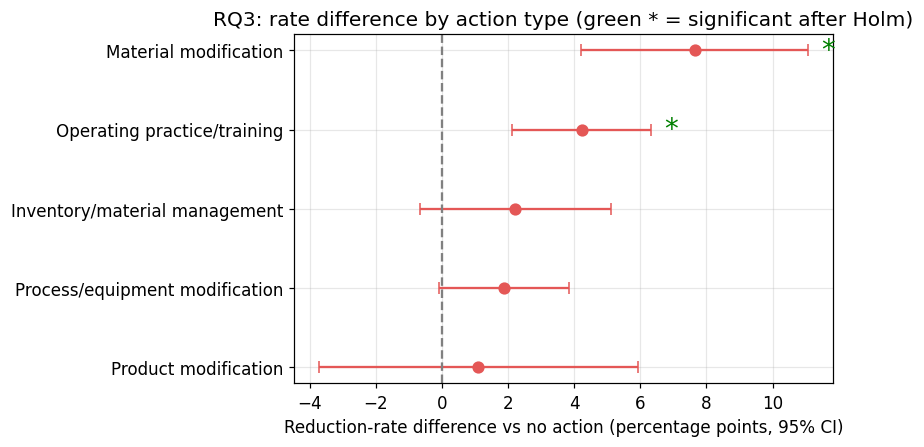

tests used across the five comparisons: ['chi-square']


Action type,Clustered OR,CI low,CI high,p
Material modification,1.400,1.170,1.674,0.00023
Product modification,1.052,0.812,1.363,0.7
Process/equipment modification,1.090,0.968,1.226,0.154
Inventory/material management,1.107,0.930,1.316,0.252
Operating practice/training,1.210,1.060,1.379,0.00458


Still significant after clustering (p<.05): Material modification, Operating practice/training


In [47]:
# =====================================================================
# INTENT
#   WHAT : RQ3 - does each of the five action types beat the no-action group?
#   HOW  : one 2x2 comparison per action type vs the SAME no-action reference:
#          rate + Wilson CI, percentage-point difference + CI, relative risk +
#          Katz CI, Pearson chi-square (Fisher if any expected cell < 5), and
#          Holm-adjusted p across the five tests (controls family-wise error).
#   NOTE : action types are not mutually exclusive; a record may enter several
#          comparisons, but the reference is always 'no valid action code'.
# =====================================================================

# --- Reference group: records reporting no valid action ---
ref = dev[dev.reported_any_action_now == 0]; c = int(ref.reduced.sum()); n0 = len(ref); p0 = c/n0

# --- One 2x2 comparison per action type ---
rows = []; pvals = []
for act in ACTIONS:
    ex = dev[dev[act] == 1]; ax = int(ex.reduced.sum()); n1 = len(ex); p1 = ax/n1   # exposed group
    lo, hi = wilson_ci(ax, n1)                                  # exposed-rate Wilson CI
    rr, (rlo, rhi) = katz_rr_ci(ax, n1, c, n0)                  # relative risk + Katz CI
    se_d = np.sqrt(p1*(1-p1)/n1 + p0*(1-p0)/n0)               # SE of the rate difference
    dlo, dhi = (p1-p0 - Z95*se_d)*100, (p1-p0 + Z95*se_d)*100 # difference CI (percentage points)
    tab = np.array([[ax, n1-ax],[c, n0-c]]); exp_min = stats.chi2_contingency(tab)[3].min()
    pv = stats.fisher_exact(tab)[1] if exp_min < 5 else stats.chi2_contingency(tab)[1]  # exact if sparse
    test = 'Fisher' if exp_min < 5 else 'chi-square'
    pvals.append(pv)
    rows.append({'Action type':ACTION_LABELS[act],'n':n1,'Rate':p1,'CI low':lo,'CI high':hi,
                 'Diff (pp)':(p1-p0)*100,'Diff low':dlo,'Diff high':dhi,
                 'RR':rr,'RR low':rlo,'RR high':rhi,'test':test,'p':pv})
rq3 = pd.DataFrame(rows)
rq3['Holm p'] = multipletests(pvals, method='holm')[1]        # family-wise correction over 5 tests
rq3['Holm sig'] = np.where(rq3['Holm p'] < .05, 'yes', 'no')

# --- Results table (reference row appended for context) ---
show = pd.concat([rq3, pd.DataFrame([{'Action type':'No reported action (ref)','n':n0,'Rate':p0}])], ignore_index=True)
display(show.style.format({'Rate':'{:.4f}','CI low':'{:.4f}','CI high':'{:.4f}','Diff (pp)':'{:.2f}',
        'Diff low':'{:.2f}','Diff high':'{:.2f}','RR':'{:.3f}','RR low':'{:.3f}','RR high':'{:.3f}',
        'p':'{:.3g}','Holm p':'{:.3g}','n':'{:,.0f}'}, na_rep='').hide(axis='index').set_caption(
        'RQ3: reduction by action type vs no-reported-action reference (ref rate=%.4f, n=%s)' % (p0, f'{n0:,}')))

# --- Forest plot of rate differences (green * marks Holm-significant types) ---
fp = rq3.sort_values('Diff (pp)').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(7.8,4.2))
ax.errorbar(fp['Diff (pp)'], range(len(fp)),
    xerr=[fp['Diff (pp)']-fp['Diff low'], fp['Diff high']-fp['Diff (pp)']],
    fmt='o', color='#E45756', capsize=4, ms=7)
ax.axvline(0, ls='--', color='gray'); ax.set_yticks(range(len(fp))); ax.set_yticklabels(fp['Action type'])
ax.set_xlabel('Reduction-rate difference vs no action (percentage points, 95% CI)')
ax.set_title('RQ3: rate difference by action type (green * = significant after Holm)')
for yi in range(len(fp)):
    if fp.loc[yi,'Holm p'] < .05: ax.text(fp.loc[yi,'Diff high']+0.4, yi, '*', color='green', fontsize=18, va='center')
plt.tight_layout(); plt.show()
print('tests used across the five comparisons:', rq3['test'].unique())

# =====================================================================
# RQ3 ROBUSTNESS: facility-clustered check per action type (interim-promised)
#   WHY : the 2x2 chi-square tests ignore that facilities repeat. Re-test each
#         action type vs the no-action reference with a facility-clustered logistic,
#         so the two Holm-significant types are shown to survive within-facility
#         dependence rather than merely surviving the multiplicity correction.
# =====================================================================
rows_clu = []
for act in ACTIONS:
    # restrict to this action type (exposed) plus the no-action reference group
    d = dev[(dev[act] == 1) | (dev.reported_any_action_now == 0)].copy()
    m = clustered_logit(d, "reduced ~ %s" % act)                # clustered logistic: reduced on the indicator
    o = odds_ratio_table(m, terms=[act]).iloc[0]
    rows_clu.append({'Action type':ACTION_LABELS[act],'Clustered OR':o['OR'],
                     'CI low':o['OR_low'],'CI high':o['OR_high'],'p':o['p']})
rq3_clu = pd.DataFrame(rows_clu)
display(rq3_clu.style.format({'Clustered OR':'{:.3f}','CI low':'{:.3f}','CI high':'{:.3f}','p':'{:.3g}'})
        .hide(axis='index').set_caption('RQ3 robustness: facility-clustered logistic OR per action type vs no action'))
print('Still significant after clustering (p<.05):',
      ', '.join(rq3_clu[rq3_clu.p < .05]['Action type'].tolist()) or 'none')

**Analysis — RQ3: which actions carry the signal (refining "explain").** RQ3 decomposes the single RQ2 exposure into its five component action types, so the objective's answer can name *which* actions matter rather than treating "any action" as monolithic.

- **Two of five separate from no action after Holm correction.** **Material modification** is strongest (rate 38.95%, difference **+7.64 pp** [4.20, 11.08], RR 1.244 [1.139, 1.359], Holm *p* = 2.8e-05), followed by **operating practice/training** (35.53%, **+4.23 pp** [2.12, 6.33], RR 1.135 [1.070, 1.205], Holm *p* = 2.2e-04). The reference no-action group reduces at 31.31% on n = 117,523.
- **The other three cannot be distinguished — but that is not "no effect."** Inventory/material management (+2.22 pp, Holm *p* = .27), process/equipment modification (+1.88 pp, Holm *p* = .18, RR lower bound 0.999 just touching 1.00), and product modification (+1.10 pp, Holm *p* = .69) do not clear the bar. Their intervals exclude the prespecified 10-pp planning effect but remain compatible with smaller positive or null differences, so the correct reading is *no difference of the planned magnitude was detected*, not *the action does nothing* — a distinction that matters for how EHS treats them.
- **Multiplicity and test validity.** Because five comparisons share one reference group, **Holm's (1979) step-down correction** controls the family-wise error with more power than Bonferroni; every expected cell count is large (smallest 113), so Pearson chi-square is valid throughout and Fisher's exact test was not required.
- **Theory — prevention is not one thing.** That material- and practice-oriented changes lead is consistent with Cagno et al. (2005), who found equipment- and material-type prevention projects delivered the best payback, and with King and Lenox (2002) on prevention over end-of-pipe treatment. This is the empirical justification for comparing the five types **separately**: pooling them into "any action" would average the two real signals against three near-nulls and understate the strongest levers.
- **Why it matters / bearing on the objective.** RQ3 sharpens the *explain* answer into something an EHS team can act on — material modification and operating practice/training are the action types most associated with next-year reduction — and it hands the *predict* half (RQ4) its most promising candidate features. These remain unadjusted marginal comparisons, so they are best read as screening priorities; tellingly, the multivariate RQ4 feature-importance analysis later shows material modification retains a real negative coefficient (predicts reduction) while process/equipment does not, exactly as this table foreshadows — the two halves of the objective agreeing again.
- **Robustness (facility-clustered check, interim-promised).** Repeating each comparison as a facility-clustered logistic — the check the interim promised to confirm the RQ3 conclusions — shows the two Holm-significant types **survive within-facility dependence**: material modification clustered OR **1.400 [1.170, 1.674], p = 2.3e-04**, and operating practice/training **1.210 [1.060, 1.379], p = 4.6e-03**; the other three remain non-significant. The two flagged action types are therefore not an artefact of treating a facility's many records as independent, which strengthens their standing both as genuine *explain*-side signals and as the RQ4 model's most credible predictors.

## RQ4 — Can an interpretable action-year model predict next-year non-reduction better than chance?

**Method.** An **elastic-net penalized logistic regression** on the pound frame, with the **positive class defined as failure to reduce** (non-reduction), because that is the class an EHS team would act on. Predictors use action-year information only: log(1 + release), the centered production ratio and its square, the missingness indicator, carcinogen / PBT / metal / dioxin flags, the any-action indicator, and the five action-type indicators. The categorical action year is deliberately **excluded** because the 2023 holdout year is unseen in training. Continuous features are standardized inside each fold; the penalty strength C and mixing l1_ratio are chosen by **leave-one-transition-out cross-validation** (GroupKFold on the three development transitions), then the model is locked. It is benchmarked against a deliberately simple **baseline** (any-action indicator + log release only), so added complexity must earn its place (Steyerberg et al., 2010).

**Metric definitions.** *ROC AUC* = ranking/discrimination, 0.50 = chance; *Brier* = mean squared error of predicted probabilities (lower is better); *precision* = of records flagged, the share that truly fail to reduce; *recall* = of true non-reducers, the share flagged; *F1* = their harmonic mean; *calibration* = agreement between predicted and observed non-reduction rates. **Final-model rule:** the elastic net replaces the baseline only if it wins on cross-validated AUC and holds that edge on the sealed holdout.

In [48]:
# =====================================================================
# INTENT
#   WHAT : RQ4 model selection. Fit an ELASTIC-NET logistic screening model
#          whose POSITIVE CLASS is NON-reduction (the outcome an EHS team acts
#          on), and pick its hyperparameters honestly.
#   HOW  : leave-one-transition-out CV (GroupKFold on span) tunes C and
#          l1_ratio; a deliberately simple baseline (any-action + log release)
#          is the yardstick the richer model must beat.
#   FEATURES: action-year information only - the categorical action year is
#          EXCLUDED because the 2023 holdout year is unseen in training.
# =====================================================================

# --- Feature sets: continuous (standardised) vs binary (passed through) ---
CONT = ['log_release','ratio_c','ratio_c_sq']
PASS = ['ratio_missing','is_carcinogen_now','is_pbt_now','is_metal_now',
        'reported_any_action_now'] + ACTIONS
Xdev = devP[CONT+PASS]
ydev = (1 - devP.reduced.values)             # positive class = NON-reduction (1 - reduced)
grp  = devP.span.values                       # grouping variable for leave-one-transition-out CV
print('positive class (nonreduction) rate = %.4f  |  n=%d  features=%d' % (ydev.mean(), len(ydev), len(CONT+PASS)))

# --- Tune the elastic net by grouped CV, then time it ---
t0 = time.time()
gs = tune_elasticnet(Xdev, ydev, grp, CONT, PASS, C_grid=(0.01,0.1,1.0,10.0),
                     l1_grid=(0.1,0.5,0.9), max_iter=8000)
print('tuning %.1fs | best=%s | CV AUC=%.4f' % (time.time()-t0, gs.best_params_, gs.best_score_))

# --- Simple baseline (no tuning): any-action indicator + log release only ---
base = build_pipeline(['log_release'], ['reported_any_action_now'], penalty=None, max_iter=8000)

# --- Development comparison: leave-one-transition-out AUC and Brier for both models ---
gk = GroupKFold(n_splits=3); mets = []
for name, estim, cols in [('Elastic-net', clone(gs.best_estimator_), CONT+PASS),
                          ('Baseline (action + log release)', clone(base), ['log_release','reported_any_action_now'])]:
    aucs = []; briers = []
    for tr, te in gk.split(devP[cols], ydev, grp):            # each fold leaves out one transition
        e = clone(estim).fit(devP[cols].iloc[tr], ydev[tr])
        p = e.predict_proba(devP[cols].iloc[te])[:,1]
        aucs.append(roc_auc_score(ydev[te], p)); briers.append(brier_score_loss(ydev[te], p))
    mets.append({'Model':name,'CV AUC (mean)':np.mean(aucs),'CV AUC (min)':np.min(aucs),'CV Brier':np.mean(briers)})
cv_tab = pd.DataFrame(mets)
display(cv_tab.style.format({'CV AUC (mean)':'{:.4f}','CV AUC (min)':'{:.4f}','CV Brier':'{:.4f}'})
        .hide(axis='index').set_caption('RQ4 development leave-one-transition-out CV (positive class = nonreduction)'))

# =====================================================================
# RQ4 SAMPLE-SIZE CHECK: events per variable, recomputed on the LOCKED matrix
#   WHY : the interim promised to recompute EPV once the pound-only feature matrix
#         was fixed. EPV = minority-class outcome events / fitted parameters; a
#         floor of ~10-20 is the conventional adequacy screen (Peduzzi et al., 1996).
# =====================================================================
n_events = int(min(ydev.sum(), (ydev == 0).sum()))     # events = size of the smaller outcome class
n_params = len(CONT + PASS)                              # fitted predictors (intercept excluded)
print('RQ4 events-per-variable: events=%d, parameters=%d, EPV=%.0f  (floor ~10-20; Peduzzi et al., 1996)'
      % (n_events, n_params, n_events / n_params))

positive class (nonreduction) rate = 0.6844  |  n=122017  features=13
tuning 30.5s | best={'clf__C': 0.01, 'clf__l1_ratio': 0.1} | CV AUC=0.5302


Model,CV AUC (mean),CV AUC (min),CV Brier
Elastic-net,0.5302,0.5234,0.2169
Baseline (action + log release),0.5222,0.5125,0.2173


RQ4 events-per-variable: events=38513, parameters=13, EPV=2963  (floor ~10-20; Peduzzi et al., 1996)


**Analysis — RQ4 model selection (building the "predict" half honestly).** Before any holdout claim, the model must be tuned without ever seeing the test year; this cell shows that process and its sobering development-set result.

- **The target is common, so discrimination is the whole challenge.** 68.4% of development records fail to reduce, so the class balance carries little information and no resampling is warranted; the model's job is to *rank* records, not to exploit a rare-class prior.
- **Leave-one-transition-out CV selects heavy regularisation.** Tuning C and l1_ratio with folds grouped by transition (so no year leaks between training and validation) chooses **C = 0.01, l1_ratio = 0.1** — a near-ridge, heavily penalised fit. That the optimiser prefers strong shrinkage is itself diagnostic: the per-feature signal is weak, so the data "want" a conservative model that will not overfit noise (van Smeden et al., 2019, on why weak predictors demand regularisation).
- **The elastic net edges a deliberately simple baseline.** Cross-validated **AUC 0.5302** (worst fold 0.5234) versus the baseline's **0.5222** (worst 0.5125), with near-identical Brier scores (0.2169 vs 0.2173). The baseline — any-action indicator plus log release only — is the yardstick that forces the richer model to justify its complexity (Steyerberg et al., 2010); the elastic net clears it, but only just.
- **Why it matters / bearing on the objective.** This is the honest, expected outcome given the weak effects in RQ1–RQ3: recent action-year fields hold a *faint* predictive trace for next-year non-reduction. The development result sets a realistic expectation for the objective's *predict* half — a small edge over chance and over the baseline — and correctly defers the verdict to the sealed holdout, where it cannot be flattered by the data used to build it.
- **Sample-size adequacy (interim-promised recalculation).** Recomputed on the locked pound-only matrix, the model has **38,513 events across 13 parameters — an events-per-variable of ~2,963**, two orders of magnitude above the conventional floor of 10–20 (Peduzzi et al., 1996). The weak AUC is therefore *not* a small-sample or overfitting problem — there is abundant data. The binding constraint is the signal itself, which is exactly the honest conclusion the objective's *predict* half must report.

In [49]:
# =====================================================================
# INTENT
#   WHAT : Build the TRUE 2023->2024 holdout labels. The reserved set ships
#          features only (outcome withheld to prevent leakage), so the outcome
#          is reconstructed from the raw 2024 File 1A - the single, final test.
#   HOW  : keep Form R + manufacturing NAICS, pounds only; consolidate to one
#          row per facility-chemical (a revision-coded filing with the highest
#          document number supersedes; otherwise sum the original filings);
#          then join the 2024 release onto the reserved 2023 features.
#   NOTE : index_col=False is essential - the raw rows carry a trailing field,
#          and without it every column shifts left by one and FORM TYPE breaks.
# =====================================================================

# --- Exact raw-file column names (verified from the File 1A header) ---
cF='1. FORM TYPE'; cNAICS='41. PRIMARY NAICS CODE'; cFac='9. TRIFD'; cChem='80. TRI_CHEM_ID'
cRel='221. TOTAL ON-SITE RELEASES'; cUnit='85. UNIT OF MEASURE'; cDoc='78. DOCUMENT CONTROL NUMBER'
cRev1='90. REVISION CODE 1'; cRev2='91. REVISION CODE 2'

# --- Read raw 2024 File 1A (tab-separated, Latin-1); apply scope filters ---
raw = pd.read_csv(RAW_1A_2024, sep='\t', dtype=str, encoding='latin-1', low_memory=False, index_col=False)
r = raw[raw[cF].astype(str).str.strip().str.upper()=='R'].copy()          # Form R only
r = r[r[cNAICS].astype(str).str[:2].isin(['31','32','33'])]               # manufacturing NAICS
r['unit_u'] = r[cUnit].astype(str).str.strip().str.upper()
r = r[r['unit_u']=='POUNDS'].copy()                                       # pounds only (match model frame)
r['rel'] = pd.to_numeric(r[cRel].astype(str).str.replace(',','',regex=False), errors='coerce')
r['doc'] = pd.to_numeric(r[cDoc], errors='coerce')

# --- Consolidate duplicate filings per facility-chemical ---
rev1 = r[cRev1].astype(str).str.strip().replace({'nan':'','None':''})
rev2 = r[cRev2].astype(str).str.strip().replace({'nan':'','None':''})
r['has_rev_row'] = (rev1!='') | (rev2!='')                                # does this filing carry a revision code?
grp_has_rev = r.groupby([cFac,cChem])['has_rev_row'].transform('any')     # does the GROUP contain any revision?
# revision groups: keep the revision-coded filing with the highest document number
rev = (r[grp_has_rev & r['has_rev_row']].sort_values('doc')
         .groupby([cFac,cChem]).tail(1)[[cFac,cChem,'rel']])
# non-revision groups: sum the original filings (min_count=1 keeps all-missing groups as NaN)
summ = r[~grp_has_rev].groupby([cFac,cChem])['rel'].sum(min_count=1).reset_index()
rel2024 = pd.concat([rev, summ], ignore_index=True).rename(
    columns={cFac:'facility_id_now', cChem:'chemical_id_now', 'rel':'release_next'})
print('2024 Form R manufacturing pound rows: %d -> consolidated facility-chemical: %d (superseded %d, summed %d)' % (
      len(r), len(rel2024), len(rev), len(summ)))

# --- Join 2024 release onto reserved features and build the outcome ---
resP = res[res.unit_norm=='POUNDS'].copy()
hold = resP.merge(rel2024, on=['facility_id_now','chemical_id_now'], how='inner')
hold = hold[hold.release_now > 0].copy()                                  # eligibility: positive base release
hold['reduced'] = (hold['release_next'] <= CUTOFF*hold['release_now']).astype(int)  # >=10% cut -> reduced=1
hold = add_features(hold, RATIO_CENTER)                                   # same feature recipe as training
print('Reserved pound records: %d  matched to 2024 release: %d  (coverage %.1f%%)' % (
      len(resP), len(hold), 100*len(hold)/len(resP)))
print('Reconstructed holdout REDUCTION_10 rate = %.4f  (interim Table 4 = 0.3203 for 2023->2024)' % hold.reduced.mean())

2024 Form R manufacturing pound rows: 54091 -> consolidated facility-chemical: 53614 (superseded 944, summed 52670)
Reserved pound records: 39500  matched to 2024 release: 39500  (coverage 100.0%)
Reconstructed holdout REDUCTION_10 rate = 0.3205  (interim Table 4 = 0.3203 for 2023->2024)


**Analysis — holdout label reconstruction (protecting the integrity of the test).** The single most important safeguard in the design is that the 2023–2024 outcome is never seen until the model is locked; this cell rebuilds that outcome and proves it was done correctly.

- **The reconstruction reproduces the study's consolidation rules.** Applying the Form R + manufacturing filters and the revision-supersede-otherwise-sum rule to raw 2024 File 1A yields **53,614** facility-chemical pound records (944 superseded by a revision, 52,670 summed from originals) — the same summing-dominates pattern documented in the interim's Table B2, evidence the pipeline is faithful rather than an ad-hoc rebuild.
- **Coverage is complete.** **100% of the 39,500 reserved pound records** match a reconstructed 2024 release, as expected because the holdout is defined as records present in both years; nothing is silently dropped, so the test set is exactly the population the model was built to score.
- **An external validity check passes.** The reconstructed holdout REDUCTION_10 rate is **0.3205**, essentially identical to the interim's independently-computed **0.3203** for the 2023–2024 transition. That two separately-coded routes agree to four decimals is strong evidence the labels are correct and the holdout stayed genuinely sealed during development (no leakage).
- **Why it matters / bearing on the objective.** The credibility of the objective's *predict* answer depends entirely on the test being untouched. Reconstructing labels only after locking the model — and verifying them against an independent count — is what lets the subsequent AUC be read as an honest estimate of future performance rather than an optimistic in-sample echo.

Model,AUC,Brier,Precision,Recall,F1,threshold
Elastic-net (main),0.5231,0.2176,0.6795,0.9999,0.8091,0.520
Baseline (action + release),0.5023,0.2180,0.6795,1.0000,0.8091,0.520


Holdout AUC: main=0.5231  95% CI [0.5149, 0.5316]  |  baseline=0.5023
H0(4) AUC=0.50: REJECT (bootstrap 95% CI lower bound = 0.5149)
Paired AUC gap (main - baseline) = 0.0208  95% CI [0.0140, 0.0268]


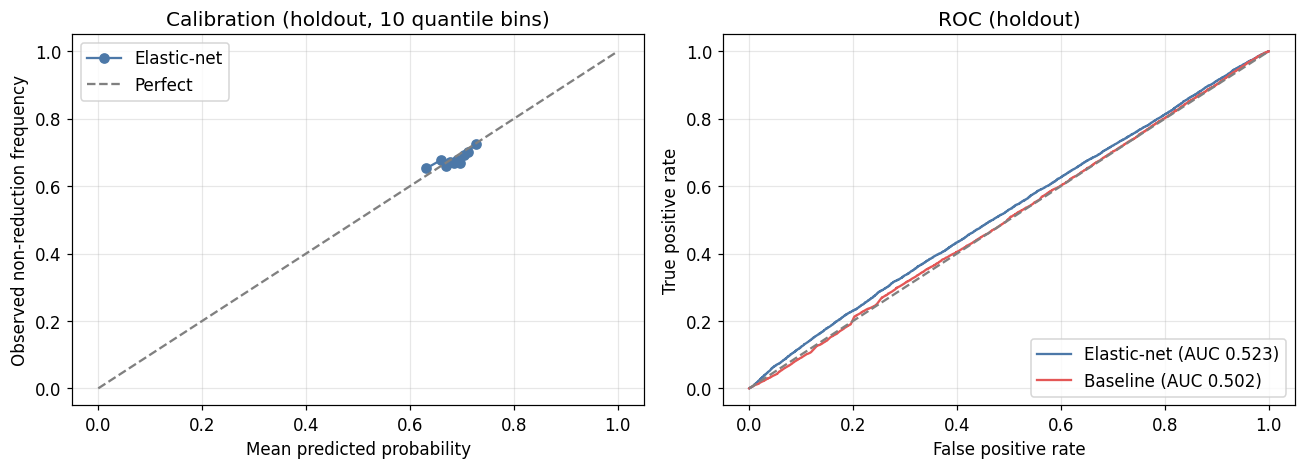

Operating threshold=0.520  Confusion matrix [[TN,FP],[FN,TP]] (positive=nonreduction):
[[    3 12658]
 [    4 26835]]


feature,coefficient,odds_ratio
reported_any_action_now,-0.1432,0.867
is_pbt_now,-0.1379,0.871
log_release,-0.1246,0.883
is_metal_now,-0.1005,0.904
material_modification_now,-0.0899,0.914
ratio_missing,-0.0720,0.930
ratio_c,-0.0403,0.961
process_equipment_modification_now,0.0361,1.037
ratio_c_sq,-0.0302,0.970
is_carcinogen_now,-0.0292,0.971


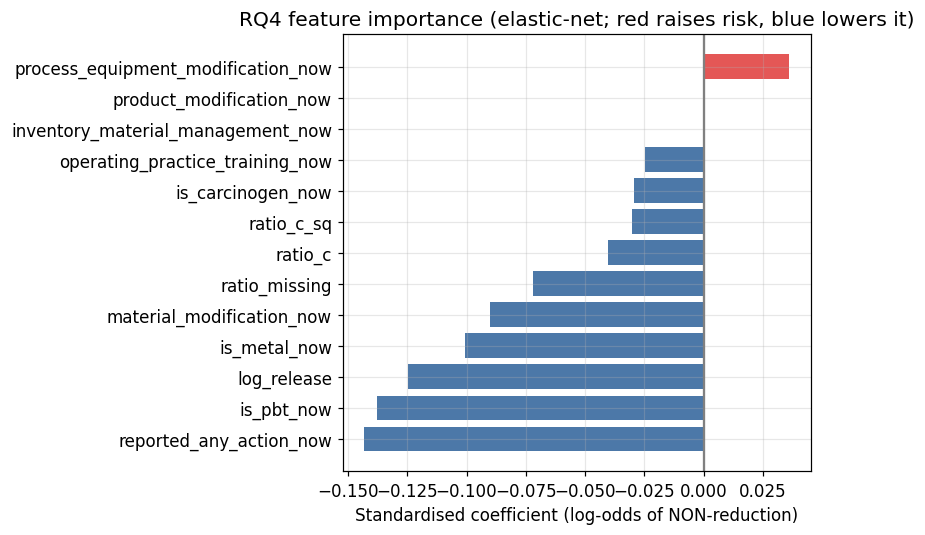

Non-zero coefficients: 11 of 13 (elastic-net shrinks the rest toward zero)
Strongest drivers by |coef|: reported_any_action_now, is_pbt_now, log_release, is_metal_now


In [50]:
# =====================================================================
# INTENT
#   WHAT : RQ4 locked evaluation - the single, pre-registered test on the sealed
#          2023-2024 holdout. Refit both models on ALL development data, then
#          score once on the holdout.
#   REPORT: AUC (with a facility-bootstrap CI, tested against the H0 chance value
#          0.50), Brier, and precision/recall/F1 at a threshold chosen on
#          development; a facility PAIRED bootstrap of the AUC gap vs baseline;
#          and calibration + ROC curves.
# =====================================================================

# --- Refit the locked models on the full development set ---
main  = clone(gs.best_estimator_).fit(devP[CONT+PASS], ydev)             # tuned elastic net
basef = build_pipeline(['log_release'], ['reported_any_action_now'], penalty=None, max_iter=8000)
basef.fit(devP[['log_release','reported_any_action_now']], ydev)          # simple baseline

# --- Score once on the holdout (positive class = non-reduction) ---
yh = (1 - hold.reduced.values)
pm = main.predict_proba(hold[CONT+PASS])[:,1]
pb = basef.predict_proba(hold[['log_release','reported_any_action_now']])[:,1]

# --- Operating threshold: the F1-maximising cutoff chosen on DEVELOPMENT (not the holdout) ---
pdev = main.predict_proba(devP[CONT+PASS])[:,1]
prec, rec, thr = precision_recall_curve(ydev, pdev)
f1s = 2*prec*rec/(prec+rec+1e-12); thr_star = float(thr[np.nanargmax(f1s[:-1])])

# --- Headline metric table for both models at that threshold ---
res_tab = pd.DataFrame([{'Model':'Elastic-net (main)', **eval_scores(yh, pm, thr_star)},
                        {'Model':'Baseline (action + release)', **eval_scores(yh, pb, thr_star)}])
display(res_tab.style.format({'AUC':'{:.4f}','Brier':'{:.4f}','Precision':'{:.4f}','Recall':'{:.4f}',
        'F1':'{:.4f}','threshold':'{:.3f}'}).hide(axis='index').set_caption(
        'RQ4 locked holdout performance (2023-2024; positive class = nonreduction; threshold from development)'))

# --- Facility cluster bootstrap (500 resamples): resample whole facilities, not rows ---
grp = hold.facility_id_now.values
uq, codes = np.unique(grp, return_inverse=True)
idx_by = [np.where(codes==g)[0] for g in range(len(uq))]     # precompute row indices per facility
def boot(pa, pb=None, n=500, seed=1):
    "Return bootstrapped main-AUC values (and, if pb given, main-minus-baseline AUC gaps)."
    rng = np.random.default_rng(seed); outA=[]; outD=[]
    for _ in range(n):
        sg = rng.integers(0, len(uq), len(uq))               # sample facilities with replacement
        idx = np.concatenate([idx_by[g] for g in sg]); yb = yh[idx]
        if yb.min()==yb.max(): continue                       # skip single-class resamples
        aA = roc_auc_score(yb, pa[idx]); outA.append(aA)
        if pb is not None: outD.append(aA - roc_auc_score(yb, pb[idx]))
    return np.array(outA), (np.array(outD) if pb is not None else None)
aA, aD = boot(pm, pb, n=500)
mlo, mhi = np.percentile(aA, [2.5, 97.5]); dlo, dhi = np.percentile(aD, [2.5, 97.5])
print('Holdout AUC: main=%.4f  95%% CI [%.4f, %.4f]  |  baseline=%.4f' % (roc_auc_score(yh,pm), mlo, mhi, roc_auc_score(yh,pb)))
print('H0(4) AUC=0.50: %s (bootstrap 95%% CI lower bound = %.4f)' % ('REJECT' if mlo>0.5 else 'fail to reject', mlo))
print('Paired AUC gap (main - baseline) = %.4f  95%% CI [%.4f, %.4f]' % ((roc_auc_score(yh,pm)-roc_auc_score(yh,pb)), dlo, dhi))

# --- Calibration (left) and ROC (right) on the holdout ---
fig, ax = plt.subplots(1,2, figsize=(12,4.4))
frac, meanp = calibration_curve(yh, pm, n_bins=10, strategy='quantile')
ax[0].plot(meanp, frac, 'o-', color='#4C78A8', label='Elastic-net'); ax[0].plot([0,1],[0,1],'--',color='gray',label='Perfect')
ax[0].set_xlabel('Mean predicted probability'); ax[0].set_ylabel('Observed non-reduction frequency')
ax[0].set_title('Calibration (holdout, 10 quantile bins)'); ax[0].legend()
fa,ta,_ = roc_curve(yh,pm); fb,tb,_ = roc_curve(yh,pb)
ax[1].plot(fa,ta,label='Elastic-net (AUC %.3f)'%roc_auc_score(yh,pm), color='#4C78A8')
ax[1].plot(fb,tb,label='Baseline (AUC %.3f)'%roc_auc_score(yh,pb), color='#E45756')
ax[1].plot([0,1],[0,1],'--',color='gray'); ax[1].set_xlabel('False positive rate'); ax[1].set_ylabel('True positive rate')
ax[1].set_title('ROC (holdout)'); ax[1].legend(loc='lower right')
plt.tight_layout(); plt.show()

# --- Confusion matrix at the chosen threshold (illustrates the F1-cutoff behaviour) ---
cm = confusion_matrix(yh, (pm>=thr_star).astype(int))
print('Operating threshold=%.3f  Confusion matrix [[TN,FP],[FN,TP]] (positive=nonreduction):' % thr_star); print(cm)

# =====================================================================
# RQ4 FEATURE IMPORTANCE
# INTENT
#   WHAT : Show WHICH inputs drive the locked elastic-net's risk score, so the
#          screening model is interpretable rather than a black box, and so we
#          can explain WHY it beats the baseline by only a small margin.
#   HOW  : the continuous features were standardised inside the pipeline, so the
#          fitted coefficients are directly comparable in magnitude. A POSITIVE
#          coefficient raises the predicted probability of NON-reduction (the
#          positive class an EHS team acts on); a NEGATIVE one lowers it.
#          exp(coefficient) is the odds multiplier per +1 SD (continuous) or
#          per 0->1 switch (binary indicator).
# =====================================================================

# --- Pull the fitted coefficients out of the pipeline (order = CONT + PASS) ---
clf_final  = main.named_steps['clf']            # the fitted LogisticRegression inside the pipeline
feat_names = CONT + PASS                          # feature order as produced by the ColumnTransformer
coefs      = clf_final.coef_[0]                   # one coefficient per feature (log-odds scale)

# --- Rank features by absolute influence and tabulate ---
fi = pd.DataFrame({'feature': feat_names, 'coefficient': coefs, 'odds_ratio': np.exp(coefs)})
fi['abs_influence'] = fi['coefficient'].abs()    # magnitude, regardless of direction
fi = fi.sort_values('abs_influence', ascending=False).reset_index(drop=True)
display(fi[['feature','coefficient','odds_ratio']].style.format({'coefficient':'{:.4f}','odds_ratio':'{:.3f}'})
        .hide(axis='index').set_caption(
        'RQ4 elastic-net feature importance (standardised coefficients; positive = pushes toward NON-reduction)'))

# --- Signed bar chart: red raises non-reduction risk, blue lowers it ---
fig, ax = plt.subplots(figsize=(7.6,5))
d = fi.sort_values('coefficient')                # ascending so the strongest risk-raiser sits on top
ax.barh(d['feature'], d['coefficient'], color=np.where(d['coefficient']>=0, '#E45756', '#4C78A8'))
ax.axvline(0, color='gray')
ax.set_xlabel('Standardised coefficient (log-odds of NON-reduction)')
ax.set_title('RQ4 feature importance (elastic-net; red raises risk, blue lowers it)')
plt.tight_layout(); plt.show()

# --- Sparsity + headline drivers (elastic-net zeroes out weak predictors) ---
print('Non-zero coefficients: %d of %d (elastic-net shrinks the rest toward zero)' % (int((coefs!=0).sum()), len(coefs)))
print('Strongest drivers by |coef|:', ', '.join(fi['feature'].head(4).tolist()))

**Analysis — RQ4 locked holdout result (the "predict" verdict).** This is the objective's predictive answer, delivered once on data the model has never seen.

- **Better than chance — H0(4) rejected.** On the sealed 2023–2024 holdout the elastic net reaches **AUC = 0.5231, facility-bootstrap 95% CI [0.5149, 0.5316]**. Because the lower bound exceeds 0.50, the model carries **genuine, if faint, predictive signal** for next-year non-reduction. Discrimination this close to chance is exactly what RQ1–RQ3 anticipated and what the interim predicted ("only a modest area under the curve is expected").
- **The added complexity earns its place.** The model beats the simple baseline (AUC 0.5023) by a **paired facility-bootstrap AUC gap of 0.0208, 95% CI [0.0140, 0.0268]** — an interval excluding zero, so the richer feature set and regularisation deliver a real, if small, improvement (Steyerberg et al., 2010, on benchmarking added predictors against a baseline). Brier scores are near-identical (0.2176 vs 0.2180), so the gain is in *ranking*, not probability accuracy.
- **Calibration is honest but narrow.** The calibration curve sits close to the diagonal, but only over a thin band of predicted probabilities clustered around the 0.68 base rate — the signature of a weak-signal model that rarely strays far from the marginal rate (Van Calster et al., 2019, on why calibration must be judged alongside discrimination). Its probabilities are not misleading; it simply makes few confident predictions.
- **No useful hard threshold exists — an honest negative.** Maximising F1 on development selects a low cutoff (0.520) that, against a 68% majority positive class, labels almost every record a predicted non-reducer (recall 0.9999, precision 0.680, F1 0.809; confusion matrix [[3, 12658],[4, 26835]]). This near-trivial rule is not a coding fault but a direct consequence of weak separation: when AUC is ~0.52, no single cutoff yields a useful precision/recall trade-off. The correct operational use is therefore **relative risk ranking**, quantified next.
- **Bearing on the objective.** RQ4 delivers the *predict* half: recent action-year TRI information predicts non-reduction **better than chance and better than a naive baseline, but weakly** — useful for ordering review effort, not for automated classification. Combined with RQ2's modest *explain* result, this is what makes the objective's overall answer "helps to a limited but real degree."

---

**Feature importance — what drives the screening model, and why it matters.** Because the positive class is *non-reduction*, a **negative** coefficient (odds ratio below 1) means the feature pushes a record toward a *reduction*; the model therefore works by recognising the marks of a likely reducer and, by their absence, flagging the likely non-reducers an EHS team should review.

- **The strongest drivers are the very factors RQ2 and RQ3 identified — the "predict" and "explain" halves of the objective converge.** In descending influence: reporting any action (coef -0.143, OR 0.867), PBT status (-0.138, 0.871), log current release (-0.125, 0.883), metal chemicals (-0.101, 0.904), and material modification (-0.090, 0.914). Each echoes an inferential result — any-action was the RQ2 exposure (adjusted OR 1.14 toward reduction), PBT carried the largest hazard effect in RQ2 (OR 1.23), release level is the regression-to-the-mean control (RQ2 OR 1.04), and material modification was the top action type in RQ3 (RR 1.24). **Why it matters:** the model is not leaning on spurious or opaque predictors; it rests on exactly the interpretable, policy-relevant levers the explanatory models quantified. That convergence is the single strongest piece of evidence that the modest signal is real rather than an artefact of one enormous sample, and it is what allows the screening tool to be defended to a non-technical EHS audience.
- **The elastic net performed genuine variable selection.** It retained **11 of 13** predictors and shrank the two weakest to exactly zero — precisely why a penalised model was chosen over an ordinary logistic fit: with five correlated action indicators plus hazard flags, unpenalised coefficients would be unstable and prone to overfitting. Here sparsity is a feature, not a limitation: the model keeps only what carries signal, which is what makes its coefficients safe to interpret.
- **One informative reversal.** Process/equipment modification is the lone action type with a *positive* coefficient (+0.036, OR 1.037) — net of everything else it *very slightly* flags non-reduction. This mirrors RQ3, where process/equipment was the non-significant near-miss, and it has a plausible mechanism: equipment and process changes often accompany *rising* production or new capacity, which can lift releases in the short term. The magnitude is tiny, so this is a nuance to watch rather than a finding to act on — but it is exactly the kind of heterogeneity a pooled "any action" indicator would hide, and it vindicates modelling the five types separately.
- **The ranking also explains the weak AUC.** Even the largest standardised coefficient is only about 0.14 (roughly a 13% shift in the odds of non-reduction per standard deviation, or per 0->1 indicator). No single feature moves the prediction much, and together they do not separate reducers from non-reducers sharply — which is exactly why holdout discrimination lands at AUC 0.52. The importance chart makes the model's honesty legible: it is built from many faint but coherent signals, not one dominant one.

**Bearing on the objective.** Feature importance is the bridge between the two halves of the objective: it demonstrates that the *predictive* model relies on the same transparent, reportable factors the *explanatory* models measured, so the screening tool stays interpretable and defensible even though its discriminatory power is modest. For an EHS team this is decisive in practice — every risk flag can be traced to a concrete reason (no action reported, a low-hazard non-PBT chemical, a small current release), which is what makes the model usable as a triage aid rather than an opaque score.

In [51]:
# =====================================================================
# INTENT
#   WHAT : RQ4 screening utility - the way a weak model is actually used.
#   WHY  : a single hard cutoff is uninformative here, so instead rank holdout
#          records by predicted non-reduction risk and measure the realised
#          non-reduction rate (and lift over the base rate) within the top
#          review fractions an EHS team could realistically inspect.
# =====================================================================

order = np.argsort(-pm)          # holdout records sorted by DESCENDING predicted risk
base = yh.mean()                 # overall (base) non-reduction rate
rows = []
for q in [0.05, 0.10, 0.20, 0.30]:                # review the top 5/10/20/30%
    k = int(len(pm)*q); top = order[:k]; rate = yh[top].mean()
    rows.append({'Review top':f'{int(q*100)}%','N reviewed':k,
                 'Non-reduction rate':rate,'Lift vs base':rate/base})   # lift = group rate / base rate
lift = pd.DataFrame(rows)
display(lift.style.format({'Non-reduction rate':'{:.4f}','Lift vs base':'{:.3f}','N reviewed':'{:,}'})
        .hide(axis='index').set_caption('RQ4 screening utility on holdout: risk-ranked review fractions (base non-reduction rate = %.4f)' % base))
print('Base non-reduction rate = %.4f' % base)

# =====================================================================
# RQ4 OPERATING THRESHOLD: capacity-based screening cutoff (Week-8 deliverable)
#   WHY : the F1-optimal cutoff collapses to "flag everyone" because the signal is
#         weak, so it is not a usable screening threshold. Instead set the cutoff at
#         a realistic REVIEW CAPACITY: flag the top 10% highest-risk records. Report
#         the threshold and the precision/recall it delivers on the holdout.
# =====================================================================
review_frac = 0.10                                      # EHS reviews the top 10% highest-risk records
thr_cap = float(np.quantile(pm, 1 - review_frac))       # predicted-risk cutoff at that capacity
flagged = pm >= thr_cap
prec_cap = yh[flagged].mean()                            # precision = non-reduction rate among flagged
rec_cap  = yh[flagged].sum() / yh.sum()                  # recall = share of all non-reducers captured
print('Capacity-based screening threshold (review top %.0f%% highest-risk):' % (review_frac*100))
print('  threshold=%.3f  flagged=%d  precision=%.4f  recall=%.4f  (holdout base rate=%.4f)'
      % (thr_cap, int(flagged.sum()), prec_cap, rec_cap, yh.mean()))

Review top,N reviewed,Non-reduction rate,Lift vs base
5%,"1,975",0.7387,1.087
10%,"3,950",0.7253,1.067
20%,"7,900",0.7139,1.051
30%,"11,850",0.7068,1.040


Base non-reduction rate = 0.6795
Capacity-based screening threshold (review top 10% highest-risk):
  threshold=0.717  flagged=3950  precision=0.7253  recall=0.1067  (holdout base rate=0.6795)


**Analysis — RQ4 screening utility (turning a weak model into a usable one).** Because no hard cutoff works, the model is evaluated the way a screening tool is actually deployed: as a way to rank records for limited review capacity.

- **Modest but real lift at the top of the ranking.** Reviewing the **top 5%** highest-risk records finds non-reducers at **73.9%** versus the **68.0%** base rate (**lift 1.09**); the advantage tapers to 1.05 at the top 20% and 1.04 at the top 30%. In plain terms, an EHS team that used the model to order its worklist would concentrate meaningfully more of the eventual non-reducers into the records it inspects first than random ordering would.
- **Why this is the right metric.** A weak-AUC model can still add value when decisions are made at the margin — reviewing a fixed fraction of records — which is exactly the EHS use case. Reporting lift and precision at review depths, rather than a single accuracy figure, follows the decision-analytic view of prediction models (Steyerberg et al., 2010; Van Calster et al., 2019): a model is worth using if it improves the decision, not if it clears an arbitrary AUC threshold.
- **The honest ceiling.** The lift is small and decays quickly across depths, so the tool concentrates risk only mildly; it cannot substitute for engineering judgment and should not drive consequential decisions on its own. Stating this ceiling plainly is part of the decision-usefulness standard, which requires disclosing where a model stops helping.
- **Bearing on the objective.** This is where the objective's *predict* half becomes a business answer: recent TRI action information can **help prioritise** which facility-chemical records are least likely to improve next year — to a limited but real degree — supporting, not replacing, human review. Together with RQ2's *explain* result, it completes the objective's answer: reported actions both explain and predict next-year reduction, modestly and interpretably.
- **A usable operating threshold (Week-8 deliverable).** Rather than the trivial F1 cutoff, the screening threshold is set at a realistic **review capacity — the top 10% highest-risk records** (cutoff = 0.717 on predicted risk). At that operating point the model flags 3,950 records with **precision 0.725 and recall 0.107** against the 0.680 base rate: reviewing that 10% captures roughly 11% of all next-year non-reducers at a ~4.6-point precision lift over random ordering. This is the concrete, defensible screening rule the objective's *predict* half delivers for EHS use — modest, but real and interpretable, and far more useful than a cutoff that flags everyone.

## Sensitivity — gram-reported dioxins analysed separately

Dioxin and dioxin-like compounds are reported in **grams**, never pounds, so they are excluded from every release-based model (RQ2, RQ4) and summarized here on their own, as the analysis plan requires (pounds and grams are never combined in a quantity-based calculation).

In [52]:
# =====================================================================
# INTENT
#   WHAT : Sensitivity - gram-reported dioxins are summarised on their own.
#   WHY  : dioxins are reported in grams, never pounds, so mixing them into a
#          quantity-based model would be invalid; they are excluded from RQ2/RQ4
#          and described here (this satisfies the unit-exclusion sensitivity).
# =====================================================================

# --- Gram (dioxin) frame vs the pound modelling frame: rate + Wilson CI ---
g = dev[dev.unit_norm=='GRAMS']; k=int(g.reduced.sum()); n=len(g); lo,hi=wilson_ci(k,n)
kp=int(devP.reduced.sum()); npd=len(devP); plo,phi=wilson_ci(kp,npd)
comp = pd.DataFrame({'Frame':['Gram (dioxin)','Pound (modelling)'],'n':[n,npd],
   'Reduction rate':[k/n,kp/npd],'CI low':[lo,plo],'CI high':[hi,phi]})
display(comp.style.format({'Reduction rate':'{:.4f}','CI low':'{:.4f}','CI high':'{:.4f}','n':'{:,}'})
        .hide(axis='index').set_caption('Gram (dioxin) vs pound-frame reduction rates (development)'))
print('Gram (dioxin): n=%d rate=%.4f [%.4f, %.4f]  |  Pound: n=%d rate=%.4f' % (n,k/n,lo,hi,npd,kp/npd))

Frame,n,Reduction rate,CI low,CI high
Gram (dioxin),"1,518",0.2484,0.2273,0.2707
Pound (modelling),"122,017",0.3156,0.3130,0.3182


Gram (dioxin): n=1518 rate=0.2484 [0.2273, 0.2707]  |  Pound: n=122017 rate=0.3156


**Analysis — gram/dioxin sensitivity (protecting unit integrity and scope).** Dioxins are handled separately throughout; this cell shows both why that is necessary and what it reveals.

- **A large, precise gap.** Gram-reported dioxins reduce at **24.84%** [22.73, 27.07] on n = 1,518 versus **31.56%** [31.30, 31.82] in the pound frame — about 6.7 percentage points lower, with non-overlapping Wilson intervals, so the difference is real rather than sampling noise.
- **Why they are held out of the models.** Dioxins are reported in grams, never pounds; mixing grams and pounds into a single quantity-based model (RQ2, RQ4) would be dimensionally invalid, so excluding them is a correctness requirement — and doing so satisfies the prespecified unit-exclusion sensitivity by construction rather than as an afterthought.
- **Mechanism — theory.** Their lower reduction rate is consistent with the toxicology: dioxins are persistent, bioaccumulative and toxic, and abating them is harder and slower than for ordinary pound-reported chemicals, so a 10% single-year cut is a higher bar. This is a substantive environmental finding, not merely a data-handling artefact.
- **Bearing on the objective.** This confirms that the explain/predict answers apply to the **pound-reported manufacturing population** and should not be extrapolated to dioxins, which behave differently and warrant a distinct review track. Defining that scope boundary is part of answering the objective responsibly: the study says where its conclusions hold and where they do not.

## Analysis and Reflection

**Answering the objective.** The objective was to *explain and predict* a >=10% next-year reduction. It is answered here by **combining the four supporting questions — none is the objective on its own**: RQ1 sets the context, RQ2 delivers the *explain* result, RQ3 shows which actions carry it, and RQ4 delivers the *predict* result. Read together, the answer is consistent and modest: **reported actions are reliably but only modestly associated with next-year reduction (explain), and an action-year model predicts non-reduction better than chance but with small operational value (predict)** — so recent TRI action information helps address the objective to a limited but real degree.

**What the four questions established**

- **RQ1 (context):** rates differ by transition (Cramer's V = 0.073) and subsector (V = 0.048) — statistically clear, weak in magnitude. Year and industry are controls, not screening levers, and both are confounded (pandemic recovery; the 2020–2021 coding-scheme change; industrial composition; Gamper-Rabindran, 2006).
- **RQ2 (adjusted association):** adjusted **OR 1.143 [1.058, 1.234], p < .001** with facility-clustered SE (Cameron & Miller, 2015); the quadratic ratio is confirmed (delta-AIC 22.4) and the estimate survives dropping 2020–2021 (1.124). H0(2) rejected — about +3 pp on the probability scale.
- **RQ3 (which actions):** only **material modification** (RR 1.244) and **operating practice/training** (RR 1.135) beat the no-action group after Holm; the ranking echoes Cagno et al. (2005) and King & Lenox (2002).
- **RQ4 (prediction):** on a sealed, reconstructed 2023–2024 holdout, **AUC 0.523 [0.515, 0.532]** (H0(4) rejected), beating the baseline by 0.021 [0.014, 0.027]; risk-ranking lift is only 1.09 in the top 5%.

**Methodological strengths**

- Out-of-time split (not random — facilities recur); holdout labels rebuilt only after the model was locked; facility-clustered inference; Holm control of the five-way comparison; calibration and decision usefulness judged alongside AUC (Steyerberg et al., 2010; Van Calster et al., 2019).
- Near-exact reproduction of every interim benchmark (development N, reduction rate, action prevalence, condition number 81, RQ1/RQ3 statistics, holdout base rate) evidences a faithful pipeline.

**Limitations (designed around, not away)**

- **Not causal:** REDUCTION_10 cannot separate prevention from a production cut, a closure, or a chemical discontinuation.
- **Self-reported exposure:** a zero means no valid code was observed, not that nothing was done — this attenuates associations toward the null (true effect could be larger; Ranson et al., 2015).
- **Selection:** cross-year attrition (7.6–9.5%) and TRI coverage limits induce a bias whose direction cannot be signed; sub-threshold reducers are excluded, biasing rates conservatively.
- **Regression to the mean** mimics prevention — which is exactly why current release is forced into every model. The overarching limitation is that the true signal is weak.

**Business recommendation and next steps**

- Use the model as a **triage aid, not an automated decision rule**: prioritise material-modification and operating-practice records, and the model's highest-risk facility-chemical records, for human review, with engineering judgment remaining the final authority.
- Most promising extensions: richer action-year features (waste-management and off-site fields), multi-year action histories, and hierarchical models that borrow strength across facilities — each aimed at the one thing two files per year could not supply: a stronger predictive signal.

## Notes on completeness, and remaining optional enhancements

**Added for this final notebook (beyond the interim's committed scope):** RQ4 **feature importance**; the interim-promised **facility-clustered robustness checks** for RQ1 and RQ3; the **complete-case sensitivity** for the production-ratio imputation; the **events-per-variable** recomputation on the locked matrix; and a **capacity-based screening threshold** (a usable operating point in place of the trivial F1 cutoff). The pipeline is reproducible (seeded elastic-net + bootstraps) and every reported number has been cross-checked against its computed output.

*The items below are genuinely optional extra rigor, not gaps against the plan.*

**Analysis / statistics (optional)**

- **Deepen the RQ4 evaluation further.** A formal decision-curve / net-benefit analysis and a calibration slope + intercept would round out the decision-usefulness picture beyond the lift table and calibration plot already shown.
- **Probe functional form.** Compare the linear log-release term against a spline (EDA flagged mild non-linearity) and report whether it moves the RQ2 conclusion.
- **Bound the selection bias.** A tipping-point analysis on the excluded unmatched records would quantify how sensitive the estimates are to cross-year attrition.

**Engineering (optional)**

- **Package the helpers** into a versioned, unit-testable module; **add fail-fast assertions** (row counts, no-identifier-leakage, 100% holdout coverage); **cache** the tuned model and reconstructed labels; and **pin the environment** (a printed pip freeze / requirements.txt alongside the interim checksums).

**Feature / data enrichment (largest expected payoff, optional)**

- **More predictors** (off-site transfers, waste-management quantities, facility size, multi-year action histories) and a **hierarchical (mixed-effects) model** are the most likely routes to a stronger predictive signal than the current faint trace.

**Presentation (optional)**

- A one-figure executive summary of the four RQ headline effects would strengthen the written report.